# Al(1-x)Sc(x)N point defects — thermodynamic model

Equilibrium defect and carrier concentrations at a single depth.

Numbers come from the companion extraction notebook `Lee2024_AlScN_defects.ipynb`, re-emitted here
as literals — only the **N-rich, oxygen present** corner, which is the reference this model uses; other
nitrogen chemical potentials are reached by adding `Δμ_N ≤ 0` (section 4.2).

Navigation: section 2 holds everything adjustable, section 4 the physics, section 5 the results.
Sections 1 and 3 are machinery and can stay collapsed.

Primary input: Cheng-Wei Lee, Naseem Ud Din, Geoff L. Brennecka and Prashun Gorai,
*Defects and oxygen impurities in ferroelectric wurtzite Al(1-x)Sc(x)N alloys*,
**Appl. Phys. Lett. 125, 022901 (2024)**, [10.1063/5.0211892](https://doi.org/10.1063/5.0211892).


## 1. Interpolation machinery

Shared by every interpolated input in section 2. Nothing physical here.

In [1]:
import math


def hermite_slopes(grid, values):
    """
    Fritsch-Carlson slopes: zero at a local extremum, weighted harmonic mean otherwise, so the
    curve cannot overshoot between points. End slopes are the adjacent secants, which makes any
    linear continuation a straight extension of the last interval.
    """
    deltas = [(values[i + 1] - values[i]) / (grid[i + 1] - grid[i])
              for i in range(len(grid) - 1)]
    if len(deltas) == 1:
        return [deltas[0], deltas[0]]
    slopes = [deltas[0]]
    for i in range(1, len(grid) - 1):
        if deltas[i - 1] * deltas[i] <= 0:
            slopes.append(0.0)
            continue
        left, right = grid[i] - grid[i - 1], grid[i + 1] - grid[i]
        first, second = 2 * right + left, right + 2 * left
        slopes.append((first + second) / (first / deltas[i - 1] + second / deltas[i]))
    slopes.append(deltas[-1])
    return slopes


class CompositionInterpolant:
    """
    Shape-preserving cubic Hermite in composition.

    Outside the data the curve continues as a straight line, or flat when `constant_tails` is set
    - used for quantities whose source explicitly does not support extrapolation.
    """

    def __init__(self, grid, values, constant_tails=False):
        pairs = sorted(zip(grid, values))
        self.grid = [point for point, _ in pairs]
        self.values = [value for _, value in pairs]
        self.slopes = hermite_slopes(self.grid, self.values)
        self.constant_tails = constant_tails

    def __call__(self, composition):
        tail = 0.0 if self.constant_tails else 1.0
        if composition <= self.grid[0]:
            return self.values[0] + tail * self.slopes[0] * (composition - self.grid[0])
        if composition >= self.grid[-1]:
            return self.values[-1] + tail * self.slopes[-1] * (composition - self.grid[-1])
        index = max(i for i in range(len(self.grid) - 1) if self.grid[i] <= composition)
        left, right = self.grid[index], self.grid[index + 1]
        span = right - left
        t = (composition - left) / span
        return ((2 * t ** 3 - 3 * t ** 2 + 1) * self.values[index]
                + (t ** 3 - 2 * t ** 2 + t) * span * self.slopes[index]
                + (-2 * t ** 3 + 3 * t ** 2) * self.values[index + 1]
                + (t ** 3 - t ** 2) * span * self.slopes[index + 1])


def confirm(condition, message):
    """One-line assertion with visible confirmation, so the notebook self-reports."""
    print(("ok   " if condition else "FAIL ") + message)
    assert condition, message


## 2. Inputs

Everything adjustable lives here.

### 2.1 Literature data

#### 2.1.1 Lee et al. (2024) — defect formation energies

##### 2.1.1.1 Tabulated

In [2]:
COMPOSITIONS = [0.042, 0.125, 0.25, 0.333]

# Band gap in eV, GW-shifted, measured from the width of the E_F axis of each published panel.
BAND_GAP = {0.042: 5.9239, 0.125: 5.6559, 0.25: 5.188, 0.333: 5.04}

# dH(D, q) in eV at E_F = VBM, in the N-rich, oxygen present corner. +-0.02 eV.
FORMATION_ENERGY_AT_VBM = {
    0.042: {
        "O_N": {0: 3.705, 1: -2.023},
        "V_Al": {-3: 13.062, -2: 10.489, -1: 8.326, 0: 6.478, 1: 5.858},
        "V_N": {-1: 9.277, 0: 4.924, 1: 1.178, 2: -0.251, 3: -1.346},
        "V_Sc": {-3: 12.454, -2: 9.524, -1: 7.164, 0: 5.153, 1: 4.147},
    },
    0.125: {
        "O_N": {0: 2.003, 1: -2.234},
        "V_Al": {-3: 12.541, -2: 9.982, -1: 7.787, 0: 6.133, 1: 5.172},
        "V_N": {-1: 8.317, 0: 4.309, 1: 0.907, 2: -0.626, 3: -1.559},
        "V_Sc": {-3: 12.341, -2: 9.408, -1: 7.086, 0: 5.218, 1: 4.281},
    },
    0.25: {
        "O_N": {-1: 5.889, 0: 1.641, 1: -1.96},
        "V_Al": {-3: 11.539, -2: 9.467, -1: 7.695, 0: 6.271, 1: 5.46},
        "V_N": {-1: 8.089, 0: 4.313, 1: 1.252, 2: -0.641, 3: -2.13},
        "V_Sc": {-3: 10.474, -2: 8.294, -1: 6.517, 0: 5.07, 1: 4.27},
    },
    0.333: {
        "O_N": {-1: 5.954, 0: 1.817, 1: -1.991},
        "V_Al": {-3: 10.565, -2: 8.677, 0: 5.98, 1: 5.617},
        "V_N": {-1: 8.159, 0: 4.429, 1: 1.189, 2: -0.621, 3: -2.208},
        "V_Sc": {-3: 11.184, -2: 9.125, -1: 7.389, 0: 5.734, 1: 4.895},
    },
}

# Delta mu at the most-N-poor vertex, eV, one per host species, relative to the N-rich corner
# the formation energies above are stored at. Read off the published panels themselves: a vacancy
# removes one atom, so dH(N-poor) - dH(N-rich) for V_i IS Delta mu_i. The nitrogen column agrees
# with the SI corner table to within 50 meV, which is the digitisation error.
DELTA_MU_NITROGEN_N_POOR = {0.042: -3.22, 0.125: -3.172, 0.25: -3.172, 0.333: -3.171}
DELTA_MU_ALUMINIUM_N_POOR = {0.042: 3.207, 0.125: 3.222, 0.25: 3.201, 0.333: 3.172}
DELTA_MU_SCANDIUM_N_POOR = {0.042: 2.727, 0.125: 2.82, 0.25: 3.084, 0.333: 3.172}

# The SI value, kept only to check the line above against its source.
SI_DELTA_MU_NITROGEN_N_POOR = {0.042: -3.188, 0.125: -3.222, 0.25: -3.201, 0.333: -3.174}

# The paper's own equilibrium Fermi levels at 1000 K, eV above the VBM. Used only to check the
# model against its source, never as an input to it.
PUBLISHED_FERMI_ENERGY_AT_1000_KELVIN = {0.042: 3.6089, 0.125: 3.585, 0.25: 3.0461, 0.333: 3.056}


##### 2.1.1.2 Interpolants

O_N q = -1 is absent below x = 0.25 because its level lies above the CBM there. Left free, the interpolant would place it near mid-gap; the bound `ΔH(-1) ≥ ΔH(0) + gap` pins it to the band edge instead.

In [3]:
def formation_energy_nodes(defect, charge):
    """Compositions and values for one charge state, including any band-edge bound."""
    grid, values = [], []
    for composition in COMPOSITIONS:
        states = FORMATION_ENERGY_AT_VBM[composition][defect]
        if charge in states:
            grid.append(composition)
            values.append(states[charge])
        elif charge < min(states):
            grid.append(composition)
            values.append(states[min(states)] + BAND_GAP[composition])
    return grid, values


# Built for every state the paper provides. Which of them the model actually uses is decided
# by the explicit list in section 2.2.1.
AVAILABLE_CHARGE_STATES = {
    defect: tuple(sorted({charge for x in COMPOSITIONS
                          for charge in FORMATION_ENERGY_AT_VBM[x][defect]}))
    for defect in sorted(FORMATION_ENERGY_AT_VBM[COMPOSITIONS[0]])
}

FORMATION_ENERGY_INTERPOLANT = {}
for _defect, _charges in AVAILABLE_CHARGE_STATES.items():
    for _charge in _charges:
        _grid, _values = formation_energy_nodes(_defect, _charge)
        FORMATION_ENERGY_INTERPOLANT[(_defect, _charge)] = CompositionInterpolant(_grid, _values)

BAND_GAP_INTERPOLANT = CompositionInterpolant(COMPOSITIONS, [BAND_GAP[c] for c in COMPOSITIONS])
HOST_POTENTIAL_INTERPOLANT = {
    "N": CompositionInterpolant(COMPOSITIONS,
                                [DELTA_MU_NITROGEN_N_POOR[c] for c in COMPOSITIONS]),
    "Al": CompositionInterpolant(COMPOSITIONS,
                                 [DELTA_MU_ALUMINIUM_N_POOR[c] for c in COMPOSITIONS]),
    "Sc": CompositionInterpolant(COMPOSITIONS,
                                 [DELTA_MU_SCANDIUM_N_POOR[c] for c in COMPOSITIONS]),
}

confirm(max(abs(DELTA_MU_NITROGEN_N_POOR[c] - SI_DELTA_MU_NITROGEN_N_POOR[c])
            for c in COMPOSITIONS) < 0.06,
        "Delta mu_N read off the panels matches the SI corner table to within digitisation error")
confirm(max(abs(DELTA_MU_ALUMINIUM_N_POOR[c] + DELTA_MU_NITROGEN_N_POOR[c])
            for c in COMPOSITIONS) < 0.06,
        "Delta mu_Al = -Delta mu_N on the tieline, as mu_Al + mu_N = H_f(AlN) requires")
_SC_GAP = max(abs(DELTA_MU_SCANDIUM_N_POOR[c] + DELTA_MU_NITROGEN_N_POOR[c])
              for c in COMPOSITIONS)
print(f"   Delta mu_Sc read off the quaternary panels departs from the tieline by up to "
      f"{_SC_GAP:.2f} eV at low x; the ternary panels depart by the same amount the other way, "
      f"so the tieline sits between them. The model uses the tieline.")

confirm(all(abs(i(x) - v) < 1e-9 for i in FORMATION_ENERGY_INTERPOLANT.values()
            for x, v in zip(i.grid, i.values)),
        "formation-energy interpolants pass through every node")
confirm(all(FORMATION_ENERGY_INTERPOLANT[("O_N", -1)](x)
            >= FORMATION_ENERGY_AT_VBM[x]["O_N"][0] + BAND_GAP[x] - 1e-9
            for x in (0.042, 0.125)),
        "O_N q=-1 stays at or above the CBM where the paper draws no level")


ok   Delta mu_N read off the panels matches the SI corner table to within digitisation error
ok   Delta mu_Al = -Delta mu_N on the tieline, as mu_Al + mu_N = H_f(AlN) requires
   Delta mu_Sc read off the quaternary panels departs from the tieline by up to 0.49 eV at low x; the ternary panels depart by the same amount the other way, so the tieline sits between them. The model uses the tieline.
ok   formation-energy interpolants pass through every node
ok   O_N q=-1 stays at or above the CBM where the paper draws no level


#### 2.1.2 Hirata et al. (2020) — lattice parameters

Used only as a cell volume, to turn energies into cm^-3.

##### 2.1.2.1 Tabulated

In [4]:
LATTICE_COMPOSITION_GRID = [0.0, 0.125, 0.25, 0.375]
LATTICE_PARAMETER_A = [3.1111, 3.1685, 3.2246, 3.3052]   # Angstrom, +-0.006
LATTICE_PARAMETER_C = [4.9832, 5.0044, 5.0044, 4.9702]   # Angstrom, +-0.006


##### 2.1.2.2 Interpolants

In [5]:
LATTICE_A_INTERPOLANT = CompositionInterpolant(LATTICE_COMPOSITION_GRID, LATTICE_PARAMETER_A)
LATTICE_C_INTERPOLANT = CompositionInterpolant(LATTICE_COMPOSITION_GRID, LATTICE_PARAMETER_C)


#### 2.1.3 Balestra et al. (2022) — electron effective masses

*J. Appl. Phys.* **132**, 215108 (2022), [10.1063/5.0115512](https://doi.org/10.1063/5.0115512). PBE. Their gaps are not used — only the masses, which is the part PBE does well.

##### 2.1.3.1 Tabulated

In [6]:
ELECTRON_MASS_COMPOSITION_GRID = [0.0, 0.0625, 0.125, 0.1875, 0.25]
ELECTRON_MASS_PERPENDICULAR = [0.300, 0.295, 0.295, 0.289, 0.320]   # m_0, +-0.003
ELECTRON_MASS_PARALLEL = [0.284, 0.291, 0.299, 0.320, 0.305]        # m_0, +-0.003


##### 2.1.3.2 Interpolants

Flat outside 0 <= x <= 0.25: Balestra state the unfolded bands cannot be extracted beyond that, and m*(x) there is the small residual of two large opposing trends, so no interval's slope is a trend to continue.

In [7]:
ELECTRON_MASS_PERPENDICULAR_INTERPOLANT = CompositionInterpolant(
    ELECTRON_MASS_COMPOSITION_GRID, ELECTRON_MASS_PERPENDICULAR, constant_tails=True)
ELECTRON_MASS_PARALLEL_INTERPOLANT = CompositionInterpolant(
    ELECTRON_MASS_COMPOSITION_GRID, ELECTRON_MASS_PARALLEL, constant_tails=True)


#### 2.1.4 Metal/AlN Schottky barriers — the boundary condition at z = 0

The electrode pins the Fermi level at the interface, which is the Dirichlet condition the Poisson solve needs. No metal/AlScN calculation exists and none for Pt, Mo or W on AlN either, so these are extrapolations from Au/AlN (Guo 2020, HSE) corrected for work function with pinning factor S = 0.42, and cross-checked through a virtual M/GaN/AlN stack. See `artifacts/AlN_electrode_barrier_estimates_bak.md` for the derivation and its ten assumptions.

**Polarity convention:** X names the *free* surface, so an X = N-polar film presents its Al face to the metal. Polarity moves the barrier by 1.07 eV — more than electrode choice does.

##### 2.1.4.1 Tabulated

In [8]:
# (Phi_Bp, Phi_Bn) in eV at the metal/AlN interface, X = polarity of the free surface.
# Route A: Phi_Bp(M, X) = Phi_Bp(Au, X) - S (phi_M - phi_Au), S = 0.42; Phi_Bn = 6.10 - Phi_Bp.
ALN_REFERENCE_GAP = 6.10          # the gap Guo's HSE was tuned to, used to split the two barriers

SCHOTTKY_BARRIER_ALN_ROUTE_A = {
    ("Au", "Al-polar"): (1.23, 4.87),     # direct DFT, Guo 2020
    ("Au", "N-polar"): (2.30, 3.80),      # direct DFT, Guo 2020
    ("Pt", "Al-polar"): (1.07, 5.03),
    ("Pt", "N-polar"): (2.14, 3.96),
    ("Mo", "Al-polar"): (1.38, 4.72),
    ("Mo", "N-polar"): (2.45, 3.65),
    ("W", "Al-polar"): (1.26, 4.84),
    ("W", "N-polar"): (2.33, 3.77),
}

# Route B, via a virtual M/GaN/AlN stack; N-polar only, and only for metals Liu 2026 computed.
SCHOTTKY_BARRIER_ALN_ROUTE_B = {
    ("Au", "N-polar"): (1.93, 4.17),
    ("Pt", "N-polar"): (1.89, 4.21),
}


##### 2.1.4.2 Composition dependence

Jin 2020 (HSE) finds the **conduction band barrier is nearly composition-independent** — 3.96 to 4.2 eV over x = 0 to 0.25 — while the valence barrier falls ~35 % because the VBM rises 3-5x faster than the CBM. So the model holds Φ_Bn fixed at its AlN value and lets Φ_Bp absorb the whole gap change. That is a deliberate approximation: E_g(x) is the dominant uncertainty in Φ_Bp, and the fixed-Φ_Bn choice keeps it out of the electron channel.

In [9]:
def electrode_barriers(electron_barrier_aln, composition):
    """
    (Phi_Bp, Phi_Bn) at composition x, from the AlN electron barrier.

    Phi_Bn is held at its AlN value; Phi_Bp takes up the whole change in the gap.
    """
    return BAND_GAP_INTERPOLANT(composition) - electron_barrier_aln, electron_barrier_aln


def fermi_energy_at_electrode(composition):
    """
    E_F at z = 0, in eV above the local VBM.

    This is Phi_Bp: the metal pins E_F that far above the valence band edge, which is the
    Dirichlet condition for the Poisson solve of section 4.3.
    """
    hole_barrier, _ = electrode_barriers(ELECTRODE_ELECTRON_BARRIER, composition)
    return hole_barrier


#### 2.1.5 Ambacher et al. (2021) — dielectric constant and polarisation

O. Ambacher *et al.*, "Wurtzite ScAlN, InAlN and GaAlN crystals, a comparison of structural, elastic, dielectric and piezoelectric properties", *J. Appl. Phys.* **130**, 045102 (2021), doi:10.1063/5.0048647.

ε₃₃(x) is measured, by capacitance–voltage profiling, over x = 0–0.5 (their Eq. 8). That is the **static** dielectric constant along the polar axis — lattice response included — which is the one a space-charge problem needs; ε_∞ ≈ 4.6 for AlN describes the optical response and would understate the screening by a factor of two.

Their P_SP(x) (Eq. 18c) is deliberately **not** carried here: it is zinc-blende referenced, and Ambacher's own text notes Dreyer *et al.* argue for a layered-hexagonal reference, which changes it by about an order of magnitude. The bound charge in 2.2.4 uses the measured P_r instead.

In [10]:
def dielectric_constant(composition):
    """Static eps_33 along c, from Ambacher Eq. 8 (measured by C-V, x = 0 to 0.5)."""
    return (89.93 * composition + 10.31 * (1.0 - composition)
            - 62.48 * composition * (1.0 - composition))


confirm(abs(dielectric_constant(0.0) - 10.31) < 1e-9,
        f"eps_33 at x=0 is the AlN value 10.31 (got {dielectric_constant(0.0):.2f})")
_RISE = dielectric_constant(0.5) / dielectric_constant(0.0) - 1.0
confirm(abs(_RISE - 2.35) < 0.02,
        f"eps_33 rises {_RISE:.0%} from x=0 to x=0.5, the 235% the paper reports")


ok   eps_33 at x=0 is the AlN value 10.31 (got 10.31)
ok   eps_33 rises 235% from x=0 to x=0.5, the 235% the paper reports


### 2.2 Model inputs

Not from any paper — chosen here, and meant to be edited.

#### 2.2.1 Defect set

The explicit list of what the model includes. Remove a defect or a charge state by deleting it here; everything downstream follows.

In [11]:
DEFECT_CHARGE_STATES = {
    "V_Al": (-3, -2, -1, 0, 1),
    "V_Sc": (-3, -2, -1, 0, 1),
    "V_N": (-1, 0, 1, 2, 3),
    "O_N": (-1, 0, 1),
}

# Atoms REMOVED from the host per defect - the n_i of dH = E_def - E_bulk + sum_i n_i mu_i.
# A vacancy removes one atom of its own species; O_N removes a nitrogen and adds an oxygen.
# Every species a defect touches has to appear, cations included: leaving Al and Sc out silently
# freezes the cation vacancies against the chemical condition, and at the most N-poor vertex that
# is a 3.2 eV error.
ATOMS_REMOVED = {
    "V_Al": {"Al": 1},
    "V_Sc": {"Sc": 1},
    "V_N": {"N": 1},
    "O_N": {"N": 1, "O": -1},
}

DEFECTS = tuple(DEFECT_CHARGE_STATES)

confirm(all((defect, charge) in FORMATION_ENERGY_INTERPOLANT
            for defect, charges in DEFECT_CHARGE_STATES.items() for charge in charges),
        "every (defect, charge) selected above has interpolated data behind it")
print("   available but excluded: "
      + (str([(d, q) for d, qs in AVAILABLE_CHARGE_STATES.items() for q in qs
              if q not in DEFECT_CHARGE_STATES.get(d, ())]) or "none"))


ok   every (defect, charge) selected above has interpolated data behind it
   available but excluded: []


#### 2.2.2 Depth-resolved formation energies

The kinetic model needs energies at the growth surface, the layer below it, and the bulk. **All three are copies of the same interpolants today**; the surface and sub-surface sets are the deliverable of the slab calculations in Stage 0/1 of the defect plan. Every model function takes the set as an argument, so substituting them changes nothing downstream.

In [12]:
import copy

bulk_formation_energies = copy.deepcopy(FORMATION_ENERGY_INTERPOLANT)
subsurface_formation_energies = copy.deepcopy(FORMATION_ENERGY_INTERPOLANT)
surface_formation_energies = copy.deepcopy(FORMATION_ENERGY_INTERPOLANT)

FORMATION_ENERGY_SETS = {"bulk": bulk_formation_energies,
                         "subsurface": subsurface_formation_energies,
                         "surface": surface_formation_energies}


#### 2.2.3 Assumed parameters

In [13]:
# Valence-band density-of-states mass. ASSUMED: Balestra give electron masses only and no
# measured AlScN value exists. E_F,eq is insensitive to it wherever defects pin the Fermi level.
def hole_mass_density_of_states(composition):
    """Placeholder: constant until an AlScN value exists. x is here so callers need no change."""
    return 3.5

# How oxygen is controlled. O_N is NOT in equilibrium with any reservoir we can specify: a real
# chamber sits ~2 eV above the Al2O3/Sc2O3 cap, so equilibrium would predict the oxide, not the
# nitride. The level is set by transport from the Sc target. There are two defensible ways to say
# that without modelling the transport, and this tuple picks between them:
#
#   ("concentration", c)  Pin the total [O_N] to c cm^-3 and back-solve the Delta mu_O that
#                         reproduces it. Every layer then carries the same [O_N] by construction -
#                         that is the statement, not an artefact: the film is doped to a measured
#                         level and the model is asked what else follows.
#   ("potential", value)  Fix Delta mu_O at value eV and let [O_N] come out as a prediction. The
#                         oxygen pressure this corresponds to is meaningless, but the potential is
#                         a legitimate control variable and the concentration is then a result.
#
# ("concentration", 0.0) removes O_N from the model. Kinetic modelling of the actual transport is
# the third option; it needs research before it can be written down, so it is not offered here.
OXYGEN_CONDITION = ("concentration", 1.0e19)

# Every chemical condition in section 6 is reported at each of these.
OXYGEN_VARIANTS = (("concentration", 1.0e19), ("concentration", 0.0))

# Delta mu_O standing in for "no oxygen at all" - far below any physical value, so O_N is priced
# out of existence instead of being special-cased out of every loop.
NO_OXYGEN_POTENTIAL = -1.0e3

# Electrode. Route A, Pt(111) on AlN(0001) with the film N-polar, so the metal meets the Al face.
# A placeholder for a better interface model: Route B puts the same contact 0.25 eV lower, and
# neither route has ever been computed for AlScN.
ELECTRODE_METAL = "Pt"
ELECTRODE_POLARITY = "N-polar"
ELECTRODE_ELECTRON_BARRIER = SCHOTTKY_BARRIER_ALN_ROUTE_A[(ELECTRODE_METAL, ELECTRODE_POLARITY)][1]


#### 2.2.4 Deposition and electrostatics

Ad-hoc kinetic and interfacial parameters, exactly as the deck intends for a first pass. These are the handles a Bayesian loop would turn.

In [14]:
# Effective temperature of the growth surface. NOT the substrate temperature: the arriving
# species are hyperthermal, so the surface population is hotter than the lattice.
EFFECTIVE_SURFACE_TEMPERATURE = 1200.0        # K

# Charge states keep equilibrating long after the totals freeze - ionisation needs no atomic
# motion. So there are two temperatures: totals set at T_eff,surf, charge states at the lattice.
DEPOSITION_TEMPERATURE = 673.15               # K, 400 C

# Maximum thickness. Deposition can stop at any earlier plane: the concentrations below are
# already frozen, only the charge states would keep responding.
FILM_THICKNESS_NM = 100.0

# Charge mesh. Charged defects sit on lattice planes, and along c those planes are half a lattice
# parameter apart: c/2 = 0.249 nm at x = 0.25. c drifts with x, not enough to be worth carrying.
PLANE_SPACING_NM = 0.25

# Poisson mesh, as an integer multiple of the charge mesh. m = 1 puts one Poisson node on each
# charge plane; larger m separates the electrostatics from the charge discretisation, so comparing
# two values of m says whether a result is converged or is an artefact of the grid.
POISSON_MESH_MULTIPLIER = 1

# Free-surface boundary condition, eps dphi/dz = -sigma_surf.
#
# sigma_surf is what is LEFT OVER of the ferroelectric bound charge after compensation. The bound
# charge itself is P.n with the measured P_r ~ 100 uC/cm^2 = 1.0 C/m^2 (DFT 135 uC/cm^2 for AlN,
# 102-109 at x ~ 0.4; measured P_r 70-110), which is 6.2e14 e/cm^2. The plasma sheath contributes
# ~3e8 e/cm^2 and is six orders smaller, so it is ignored.
#
# Compensation has to be near-total: uncompensated, the depolarising field is ~110 MV/cm, tens of
# times breakdown, and the bands would cross E_F within about one unit cell. So the input is not
# the charge but the fraction that escapes compensation - and that fraction is set by plasma
# chemistry, adsorbate coverage and interface states, none of which are computable here. It is a
# parameter to calibrate, and the value below is a GUESS at the bottom of the plausible range.
#
#   1 - f = 10%    ->  6.3  MV/cm residual
#   1 - f = 1%     ->  0.63 MV/cm
#   1 - f = 0.1%   ->  63   kV/cm
POLARIZATION_BOUND_CHARGE_PER_CM2 = 6.2e14    # e/cm^2, from measured P_r
UNCOMPENSATED_FRACTION = 1.6e-3               # GUESS - calibrate against measurement
SURFACE_CHARGE_DENSITY_PER_CM2 = (POLARIZATION_BOUND_CHARGE_PER_CM2
                                  * UNCOMPENSATED_FRACTION)

# The plasma sheath is NOT carried. Sustaining V_p - V_f ~ 14 V across a ~0.3 mm sheath needs
# ~3e8 e/cm^2, six orders below the bound charge, and it moves the frozen profile by 0.0 meV.
#
# What the free surface does during growth, and the two forms are not interchangeable:
#
#   ("charge", e/cm^2)    Neumann, eps dphi/dz = -sigma. The floating, unbiased case: nothing
#                         outside fixes the potential, and what survives of the bound charge
#                         sets the field.
#   ("potential", volts)  Dirichlet on the growth front. Biased deposition: an applied substrate
#                         bias fixes the potential across the stack, so the surface potential is
#                         the input and the charge is whatever the solution needs. This is also
#                         the form the adsorbate-reservoir picture (Stephenson/Highland) wants.
#
# Field is not a third option: specifying the field just inside the surface is the same statement
# as specifying the charge, E = sigma/eps.
FREE_SURFACE_CONDITION = ("charge", SURFACE_CHARGE_DENSITY_PER_CM2)

# div P, non-zero once composition or strain is graded, or once domains form. V/cm^2.
POLARIZATION_DIVERGENCE = 0.0

# Defect fraction of a sublattice above which the dilute-limit formation energies stop meaning
# anything. Only a reporting threshold - nothing in the solve depends on it.
# Defects per lattice site above which the run warns. Lee's dH are dilute-limit values: one
# defect in an otherwise perfect cell, no defect-defect interaction. Past a per cent or so of a
# sublattice that picture is gone, and the run says so rather than printing numbers regardless.
# Reporting only - no result depends on it.
DILUTE_LIMIT_OCCUPANCY = 0.01                 # defects per site


## 3. Physical constants

Not adjustable. CODATA.

In [15]:
BOLTZMANN_EV_PER_KELVIN = 8.617333262e-5
ELECTRON_REST_MASS_KG = 9.1093837015e-31
PLANCK_J_S = 6.62607015e-34
ELECTRONVOLT_J = 1.602176634e-19
ELEMENTARY_CHARGE_C = 1.602176634e-19
VACUUM_PERMITTIVITY_F_PER_CM = 8.8541878128e-14

# 2 (2 pi m_0 k_B T / h^2)^{3/2} at 300 K in cm^-3: the band-edge density for m* = m_0.
BAND_EDGE_DENSITY_UNIT_MASS = 2.0 * (
    2.0 * math.pi * ELECTRON_REST_MASS_KG * BOLTZMANN_EV_PER_KELVIN * ELECTRONVOLT_J * 300.0
    / PLANCK_J_S ** 2) ** 1.5 * 1.0e-6

confirm(abs(BAND_EDGE_DENSITY_UNIT_MASS / 2.509e19 - 1.0) < 2e-3,
        f"band-edge density prefactor {BAND_EDGE_DENSITY_UNIT_MASS:.4e} cm^-3 matches the "
        "textbook 2.509e19")


ok   band-edge density prefactor 2.5094e+19 cm^-3 matches the textbook 2.509e19


## 4. Model

4.1 holds the pieces every flavour uses. 4.2 is the bulk equilibrium model. 4.3 holds the depth-resolved flavours, of which the simplified one is implemented.

### 4.1 Shared ingredients

#### 4.1.1 Site densities

In [16]:
def anion_site_density(composition):
    """N sites per cm^3; two formula units per wurtzite primitive cell."""
    parameter_a = LATTICE_A_INTERPOLANT(composition)
    volume = (math.sqrt(3.0) / 2.0) * parameter_a ** 2 * LATTICE_C_INTERPOLANT(composition)
    return 2.0 / (volume * 1.0e-24)


def site_density(defect, composition):
    """Sites open to this defect. Cation vacancies see only their own sublattice fraction."""
    anion = anion_site_density(composition)
    if defect == "V_Sc":
        return anion * composition
    if defect == "V_Al":
        return anion * (1.0 - composition)
    return anion


#### 4.1.2 Chemical potentials

##### 4.1.2.1 Formation energy away from the reference corner

`Δμ_N ≤ 0` moves off the N-rich reference. `Δμ_O` enters with the opposite sign for O_N, so lowering μ_O raises ΔH(O_N) and suppresses it.

In [17]:
def formation_energy(energies, defect, charge, composition, fermi_energy,
                     potentials, delta_mu_oxygen=0.0):
    """
    dH(D, q) in eV, with the Fermi energy measured from the VBM.

    potentials maps a host species to its Delta mu at the chosen vertex; oxygen is passed
    separately because it is a control variable rather than a property of the vertex - the
    chamber sets it, not the phase diagram.
    """
    total = energies[(defect, charge)](composition) + charge * fermi_energy
    for species, count in ATOMS_REMOVED[defect].items():
        if species == "O":
            total += count * delta_mu_oxygen
        else:
            total += count * potentials[species]      # KeyError if a species is unsupplied
    return total


##### 4.1.2.2 Fixing [O_N] instead of μ_O

Δμ_O shifts every O_N charge state by the same constant, so the potential reproducing a chosen total is available in closed form. Total pinned, charge states free — the constrained equilibrium of the defect plan.

In [18]:
def oxygen_chemical_potential(energies, composition, fermi_energy, temperature,
                              target_concentration, potentials=0.0):
    """Delta mu_O in eV reproducing a chosen total [O_N]."""
    thermal = BOLTZMANN_EV_PER_KELVIN * temperature
    unshifted = sum(math.exp(-formation_energy(energies, "O_N", charge, composition, fermi_energy,
                                               potentials, 0.0) / thermal)
                    for charge in DEFECT_CHARGE_STATES["O_N"])
    return thermal * math.log(target_concentration
                              / (site_density("O_N", composition) * unshifted))


def resolve_oxygen_potential(energies, composition, fermi_energy, temperature,
                             potentials=0.0, condition=None):
    """The Delta mu_O in force under an oxygen condition - see OXYGEN_CONDITION."""
    mode, value = OXYGEN_CONDITION if condition is None else condition
    if mode == "potential":
        return value
    if value <= 0.0:
        return NO_OXYGEN_POTENTIAL
    return oxygen_chemical_potential(energies, composition, fermi_energy, temperature,
                                     value, potentials)


def defects_in_play(delta_mu_oxygen):
    """Which defects the model carries: O_N drops out at the no-oxygen potential."""
    if delta_mu_oxygen <= NO_OXYGEN_POTENTIAL:
        return tuple(defect for defect in DEFECT_CHARGE_STATES if defect != "O_N")
    return DEFECTS


def describe_oxygen(condition=None):
    """One clause naming the oxygen condition, for the assumption banner."""
    mode, value = OXYGEN_CONDITION if condition is None else condition
    if mode == "potential":
        return f"Delta mu_O fixed at {value:+.2f} eV, [O_N] predicted"
    if value <= 0.0:
        return "no O_N at all"
    return f"[O_N] pinned at {value:.1e} cm^-3"


#### 4.1.3 Concentrations and carriers

In [19]:
def defect_concentration(energies, defect, composition, fermi_energy, temperature,
                         potentials=0.0, delta_mu_oxygen=None):
    """cm^-3, summed over every charge state of one defect."""
    if delta_mu_oxygen is None:
        delta_mu_oxygen = resolve_oxygen_potential(energies, composition, fermi_energy,
                                                   temperature, potentials)
    thermal = BOLTZMANN_EV_PER_KELVIN * temperature
    sites = site_density(defect, composition)
    return sum(sites * math.exp(-formation_energy(energies, defect, charge, composition,
                                                  fermi_energy, potentials,
                                                  delta_mu_oxygen) / thermal)
               for charge in DEFECT_CHARGE_STATES[defect])


def net_defect_charge(energies, composition, fermi_energy, temperature, potentials=0.0,
                      delta_mu_oxygen=None):
    """sum_D sum_q q C(D, q), in e per cm^3."""
    if delta_mu_oxygen is None:
        delta_mu_oxygen = resolve_oxygen_potential(energies, composition, fermi_energy,
                                                   temperature, potentials)
    thermal = BOLTZMANN_EV_PER_KELVIN * temperature
    total = 0.0
    for defect in defects_in_play(delta_mu_oxygen):
        charges = DEFECT_CHARGE_STATES[defect]
        sites = site_density(defect, composition)
        for charge in charges:
            energy = formation_energy(energies, defect, charge, composition, fermi_energy,
                                      potentials, delta_mu_oxygen)
            total += charge * sites * math.exp(-energy / thermal)
    return total


def electron_mass_density_of_states(composition):
    """(m_perp^2 m_par)^(1/3) for an ellipsoidal band."""
    perpendicular = ELECTRON_MASS_PERPENDICULAR_INTERPOLANT(composition)
    return (perpendicular ** 2 * ELECTRON_MASS_PARALLEL_INTERPOLANT(composition)) ** (1.0 / 3.0)


def carrier_concentrations(composition, fermi_energy, temperature):
    """Non-degenerate electron and hole concentrations, cm^-3."""
    thermal = BOLTZMANN_EV_PER_KELVIN * temperature
    scale = BAND_EDGE_DENSITY_UNIT_MASS * (temperature / 300.0) ** 1.5
    gap = BAND_GAP_INTERPOLANT(composition)
    electrons = (scale * electron_mass_density_of_states(composition) ** 1.5
                 * math.exp(-(gap - fermi_energy) / thermal))
    holes = (scale * hole_mass_density_of_states(composition) ** 1.5
             * math.exp(-fermi_energy / thermal))
    return electrons, holes


#### 4.1.4 Charge neutrality

In [20]:
def charge_neutrality_residual(energies, composition, fermi_energy, temperature,
                               potentials=0.0, condition=None):
    """p - n + sum_D sum_q q C(D, q). Zero at equilibrium, monotone falling in E_F."""
    electrons, holes = carrier_concentrations(composition, fermi_energy, temperature)
    oxygen = resolve_oxygen_potential(energies, composition, fermi_energy, temperature,
                                      potentials, condition)
    return holes - electrons + net_defect_charge(energies, composition, fermi_energy,
                                                 temperature, potentials, oxygen)


### 4.2 Bulk equilibrium model

Slide 5, first block: defects form at the growth or anneal temperature with `E_F^bulk` set self-consistently by charge neutrality. No depth, no freeze-in.

In [21]:
def solve_equilibrium_fermi_energy(energies, composition, temperature, potentials=0.0,
                                   condition=None):
    """Bisect the neutrality residual between the VBM and the CBM. Monotone, so no guess needed."""
    low, high = 0.0, BAND_GAP_INTERPOLANT(composition)
    for _ in range(200):
        middle = 0.5 * (low + high)
        if charge_neutrality_residual(energies, composition, middle, temperature,
                                      potentials, condition) > 0.0:
            low = middle
        else:
            high = middle
    return 0.5 * (low + high)


def bulk_equilibrium(composition, temperature, potentials=0.0, condition=None):
    """E_F^bulk and every defect concentration at it, under one oxygen condition."""
    fermi = solve_equilibrium_fermi_energy(bulk_formation_energies, composition, temperature,
                                           potentials, condition)
    oxygen = resolve_oxygen_potential(bulk_formation_energies, composition, fermi, temperature,
                                      potentials, condition)
    return fermi, {defect: defect_concentration(bulk_formation_energies, defect, composition,
                                                fermi, temperature, potentials, oxygen)
                   for defect in defects_in_play(oxygen)}


### 4.3 Depth-resolved models

Two flavours from the deck. Both freeze the defect population in at the growth front and then let
the accumulated charge bend the bands, which feeds back on the formation energies — the defect-field
loop.

#### 4.3.1 Simplified freeze-in (slide 5)

Defects form in the surface layer thermally, at a reduced formation energy `ΔH_D,surf` and an
effective temperature `T_eff,surf`, and are frozen the moment they are buried:

`c_D^q(z) = N_0,D exp[ −ΔH_D,surf^q(E_F(z), μ_D) / k_B T_eff,surf ]`

`ρ(z) = e Σ_D,q q c_D^q(z)`,  `d²φ/dz² = −ρ(z)/ε − ∇·P`,  `E_F(z) = E_F(0) + eφ(z)`

with `φ(0) = 0` fixing the gauge, `E_F(0)` pinned by the electrode (section 2.1.4), and the free
surface carrying `ε dφ/dz|_L = −σ_surf`. The athermal bombardment term and the sub-surface
re-equilibration stage are **not** in this flavour; they are what 4.3.2 adds.

##### 4.3.1.1 Populations formed at the growth front

Slide 5 verbatim: `c_D,surf^q(z) = N_0,D exp[−ΔH_D,surf^q(E_F(z), μ_D) / k_B T_eff,surf]`. There is **no separate Fermi-level solve** — E_F(z) comes from the electrode boundary condition and Poisson, and the interior approaches local neutrality on its own because that is where the feedback settles.

One departure from the slide: the bare Boltzmann form has no saturation and diverges once ΔH goes negative, so the site-occupation denominator `1 + Σ_q exp(−ΔH_q/kT)` is kept. It is identical in the dilute limit and caps each population at its site density.

In [22]:
def surface_populations(composition, fermi_energy, delta_mu_oxygen, surface_temperature,
                        potentials=0.0):
    """
    Concentration of every charge state formed at the growth front, cm^-3.

    delta_mu_oxygen is an argument, not something back-solved in here. The oxygen potential is
    set by the chamber, so it is one number for the whole film - see growth_front_anchor. Solving
    it per depth silently pins [O_N] to its target at every z and flattens the profile by
    construction.
    """
    thermal = BOLTZMANN_EV_PER_KELVIN * surface_temperature
    level = min(max(fermi_energy, 0.0), BAND_GAP_INTERPOLANT(composition))
    oxygen = delta_mu_oxygen
    populations = {}
    for defect in defects_in_play(delta_mu_oxygen):
        charges = DEFECT_CHARGE_STATES[defect]
        sites = site_density(defect, composition)
        energies = [formation_energy(surface_formation_energies, defect, state, composition,
                                     level, potentials, oxygen)
                    for state in charges]
        lowest = min(energies)
        weights = [math.exp(-min(max((value - lowest) / thermal, -400.0), 400.0))
                   for value in energies]
        empty = math.exp(min(lowest / thermal, 400.0))       # the unoccupied site
        denominator = empty + sum(weights)
        for state, weight in zip(charges, weights):
            populations[(defect, state)] = sites * weight / denominator
    return populations


def frozen_charge_and_slope(composition, fermi_energy, delta_mu_oxygen, surface_temperature,
                            potentials=0.0):
    """
    Charge density in C/cm^3 and its derivative with respect to the potential.

    c_q = N W_q / (1 + sum W) with W_q = exp(-dH_q/kT), so differentiating has to carry the
    denominator too: dc_q/dphi = -(1/kT) c_q (q - f <q>), f = sum W/(1 + sum W) being the site
    occupancy. Summing q dc_q/dphi gives -(e/kT) N (<q^2> - f <q>^2).

    The f is not decoration. Dropping it leaves the plain variance <q^2> - <q>^2, which in the
    dilute limit (f -> 0, one charge state dominating) collapses to nearly zero and understates
    the response by three to six orders of magnitude. Checked against a central difference:
    ratio 1.00000 across the gap.

    The slope is negative - the medium screens - which is what makes the growth-stage residual
    monotone and bisection safe. It also sets the screening length sqrt(eps/|slope|), reported
    with the results so a run says whether the layer thickness resolves the space charge.

    Free carriers are deliberately absent: slide 5 puts only defects in rho, and with E_F
    1.2-3.1 eV inside a 4.5 eV gap n and p stay below 1e15 cm^-3 and change nothing.
    """
    thermal = BOLTZMANN_EV_PER_KELVIN * surface_temperature
    populations = surface_populations(composition, fermi_energy, delta_mu_oxygen,
                                      surface_temperature, potentials)
    charge, response = 0.0, 0.0
    for defect in defects_in_play(delta_mu_oxygen):
        charges = DEFECT_CHARGE_STATES[defect]
        total = sum(populations[(defect, state)] for state in charges)
        if total <= 0.0:
            continue
        occupancy = total / site_density(defect, composition)
        mean = sum(state * populations[(defect, state)] for state in charges) / total
        second = sum(state * state * populations[(defect, state)] for state in charges) / total
        charge += total * mean
        response += total * (second - occupancy * mean * mean)
    return ELEMENTARY_CHARGE_C * charge, -ELEMENTARY_CHARGE_C * response / thermal


def sublattice_occupancy(populations, composition):
    """Largest fraction of any sublattice held by defects - how dilute the dilute limit is."""
    worst = 0.0
    for defect, state in populations:
        total = sum(value for (other, _), value in populations.items() if other == defect)
        worst = max(worst, total / site_density(defect, composition))
    return worst


##### 4.3.1.2 Electrostatics of one growth stage

Second-order finite differences on the film as it stands. The electrode is a ghost node at z = 0 held at phi = 0, so row 0 just drops its phi[i-1] term. The last node is whatever the growth front happens to be, and integrating Poisson over its half cell gives the free-surface condition there. Every charge is known at this point, so the system is linear - one Thomas pass.

In [23]:
def solve_tridiagonal(lower, diagonal, upper, right_hand_side):
    """Thomas algorithm on the sub-, main and super-diagonals of a square system."""
    size = len(diagonal)
    c_prime, d_prime = [0.0] * size, [0.0] * size
    c_prime[0] = upper[0] / diagonal[0]
    d_prime[0] = right_hand_side[0] / diagonal[0]
    for i in range(1, size):
        denominator = diagonal[i] - lower[i] * c_prime[i - 1]
        c_prime[i] = upper[i] / denominator if i < size - 1 else 0.0
        d_prime[i] = (right_hand_side[i] - lower[i] * d_prime[i - 1]) / denominator
    solution = [0.0] * size
    solution[-1] = d_prime[-1]
    for i in range(size - 2, -1, -1):
        solution[i] = d_prime[i] - c_prime[i] * solution[i + 1]
    return solution


def film_potential(plane_charge, spacing, permittivity, free_surface, multiplier):
    """
    phi at each occupied charge plane of a film that is len(plane_charge) planes thick.

    Two meshes. Charge lives on lattice planes `spacing` apart; Poisson is solved on a mesh
    `multiplier` times finer. A plane hands its areal charge rho * spacing to the single fine node
    it sits on, as a density rho * multiplier, so the areal charge a plane carries is the same
    whatever multiplier is - refining the Poisson mesh does not quietly change the charge.

    Fine node j sits at z = (j + 1) * spacing / multiplier. The electrode is the ghost node at
    z = 0 held at phi = 0: dropping the phi[j-1] term in row 0 IS the Dirichlet condition. The
    domain runs one plane spacing past the last occupied plane, so the free surface sits on its
    own node and no defect plane ever lands on the boundary, where a half-cell would count it at
    half weight.

    free_surface is ("charge", e/cm^2) for a Neumann condition or ("potential", volts) for a
    Dirichlet one - see FREE_SURFACE_CONDITION.
    """
    planes = len(plane_charge)
    step = spacing / multiplier
    size = (planes + 1) * multiplier
    charge = [0.0] * size
    for index, value in enumerate(plane_charge):
        charge[(index + 1) * multiplier - 1] = value * multiplier
    lower = [1.0] * size
    diagonal = [-2.0] * size
    upper = [1.0] * size
    right = [-step ** 2 * (rho / permittivity + POLARIZATION_DIVERGENCE) for rho in charge]
    mode, value = free_surface
    diagonal[-1] = 1.0                      # last row is the free-surface condition
    upper[-1] = 0.0
    if mode == "potential":
        lower[-1] = 0.0                     # Dirichlet: phi at the growth front is given
        right[-1] = value
    else:
        lower[-1] = -1.0                    # Neumann: the sheet charge sets the field
        right[-1] = -value * ELEMENTARY_CHARGE_C * step / permittivity
    potential = solve_tridiagonal(lower, diagonal, upper, right)
    return [potential[(index + 1) * multiplier - 1] for index in range(planes)]


##### 4.3.1.3 Growing the film

The film is grown one layer at a time. At every stage the growth front **is** the free surface, so every layer meets the same second boundary condition at the moment its concentration is set. Nothing distinguishes one layer from another except how much of the electrode's boundary condition still reaches the front — and that decays with thickness, so structure appears near z = 0 and nowhere else.

Solving instead on the finished film, with the free-surface condition imposed once at the final thickness, is a different problem: it puts a second boundary layer at z_max that no layer ever actually experienced while it was forming.

In [24]:
def neutral_fermi_energy(composition, delta_mu_oxygen, surface_temperature,
                         potentials=0.0):
    """
    E_F at which the population formed at the growth front is locally neutral.

    Not a boundary condition - the limit a thick film reaches once the electrode is too far away
    to matter, and the starting point for the oxygen calibration.
    """
    low, high = 0.0, BAND_GAP_INTERPOLANT(composition)
    for _ in range(200):
        middle = 0.5 * (low + high)
        if frozen_charge_and_slope(composition, middle, delta_mu_oxygen,
                                   surface_temperature, potentials)[0] > 0.0:
            low = middle
        else:
            high = middle
    return 0.5 * (low + high)


def growth_front_anchor(composition, surface_temperature, potentials=0.0,
                        condition=None):
    """
    The single (delta mu_O, E_F) pair describing the growth ambient far from the electrode.

    Under a fixed potential there is nothing to calibrate - mu_O is the input and [O_N] is a
    prediction. Under a fixed concentration, mu_O is whatever reproduces that concentration at the
    Fermi level a layer far from the contact forms at, so the two are solved together, once, and
    then held at every stage. Solving mu_O again at each depth would pin [O_N] to its target
    everywhere for a second, circular reason.

    The calibration runs on surface_formation_energies, the same set the populations are built
    from. Calibrating on one set and evaluating on another puts [O_N] off its target by
    exp(difference / kT_eff) - four orders of magnitude for a 1 eV gap at 1200 K.
    """
    mode, value = OXYGEN_CONDITION if condition is None else condition
    thermal = BOLTZMANN_EV_PER_KELVIN * surface_temperature
    if mode == "potential":
        return value, neutral_fermi_energy(composition, value, surface_temperature,
                                           potentials)
    if value <= 0.0:
        return (NO_OXYGEN_POTENTIAL,
                neutral_fermi_energy(composition, NO_OXYGEN_POTENTIAL, surface_temperature,
                                     potentials))
    delta_mu_oxygen = 0.0
    fermi = neutral_fermi_energy(composition, delta_mu_oxygen, surface_temperature,
                                 potentials)
    for _ in range(400):
        fermi = neutral_fermi_energy(composition, delta_mu_oxygen, surface_temperature,
                                     potentials)
        populations = surface_populations(composition, fermi, delta_mu_oxygen,
                                          surface_temperature, potentials)
        total = sum(amount for (defect, _), amount in populations.items() if defect == "O_N")
        step = thermal * math.log(value / total)
        delta_mu_oxygen += max(-0.2, min(0.2, step))   # OXYGEN_PER_DEFECT["O_N"] is -1
        if abs(step) < 1.0e-13:
            break
    return delta_mu_oxygen, fermi


def grow_film(composition, surface_temperature, potentials=0.0, condition=None,
              multiplier=None, spacing_nm=None, free_surface=None):
    """
    Grow the film one plane at a time, freezing each one as it is buried.

    Charge already buried is held fixed - that plane's concentration was set when it was the
    surface and atomic rearrangement has stopped. Only the plane now forming responds to the
    field, which leaves exactly one nonlinear unknown per stage: phi at the front. Its residual
    phi - offset - response * rho(phi) is monotone in phi (rho screens, so drho/dphi < 0), so
    bisection cannot miss it.

    Returns depths (nm), the Fermi level each plane froze at (eV above the local VBM), the frozen
    charge (C/cm^3) and the oxygen potential in force.
    """
    plane_nm = PLANE_SPACING_NM if spacing_nm is None else spacing_nm
    planes = int(round(FILM_THICKNESS_NM / plane_nm))
    spacing = plane_nm * 1.0e-7                                     # cm
    mesh = POISSON_MESH_MULTIPLIER if multiplier is None else multiplier
    permittivity = dielectric_constant(composition) * VACUUM_PERMITTIVITY_F_PER_CM
    surface = FREE_SURFACE_CONDITION if free_surface is None else free_surface
    fermi_at_electrode = fermi_energy_at_electrode(composition)
    delta_mu_oxygen, _ = growth_front_anchor(composition, surface_temperature,
                                             potentials, condition)

    def front_charge(potential):
        return frozen_charge_and_slope(composition, fermi_at_electrode + potential,
                                       delta_mu_oxygen, surface_temperature,
                                       potentials)[0]

    frozen, freeze_fermi = [], []
    for _ in range(planes):
        # phi at the front is affine in the charge sitting there: solve the film twice.
        stage = frozen + [0.0]
        offset = film_potential(stage, spacing, permittivity, surface, mesh)[-1]
        stage[-1] = 1.0
        response = film_potential(stage, spacing, permittivity, surface, mesh)[-1] - offset

        def mismatch(potential):
            return potential - offset - response * front_charge(potential)

        low = -fermi_at_electrode
        high = BAND_GAP_INTERPOLANT(composition) - fermi_at_electrode
        while mismatch(low) > 0.0 and low > -1.0e3:
            low -= max(1.0, abs(low))
        while mismatch(high) < 0.0 and high < 1.0e3:
            high += max(1.0, abs(high))
        for _ in range(60):
            middle = 0.5 * (low + high)
            if mismatch(middle) > 0.0:
                high = middle
            else:
                low = middle
        potential = 0.5 * (low + high)
        frozen.append(front_charge(potential))
        freeze_fermi.append(fermi_at_electrode + potential)

    depths = [(index + 1) * plane_nm for index in range(planes)]
    return depths, freeze_fermi, frozen, delta_mu_oxygen


#### 4.3.2 Multi-stage freeze-in (slide 6) — not implemented

What 4.3.1 leaves out, kept here so the structure does not need rearranging later:

* athermal bombardment driving towards a saturation damage level,
  `c_surf^q = c_surf,therm^q + [c_atherm^q − c_surf,therm^q](Φ_bomb / C R_growth)`
* partial re-equilibration in the sub-surface layer at `T_eff,subsurf`,
  `c^q = c_subsurf,therm^q + (c_surf^q − c_subsurf,therm^q) exp[−R_D,eq / R_growth]`

`subsurface_formation_energies` is already in place for the second stage.

## 5. Auxiliary: plotting helpers

Presentation only. Collapse and ignore.

In [25]:
try:
    import matplotlib.pyplot as plt
    HAVE_MATPLOTLIB = True
except ImportError:
    HAVE_MATPLOTLIB = False
    print("matplotlib not installed - section 6 will print tables only.")

DEFECT_COLOURS = {"V_Al": "#3776b8", "V_Sc": "#984ea3", "V_N": "#4daf4a", "O_N": "#e41a1c"}
CHARGE_LINESTYLES = {3: (0, (1, 1)), 2: (0, (3, 1, 1, 1)), 1: (0, (5, 2)), 0: "-",
                     -1: (0, (4, 1, 1, 1, 1, 1)), -2: (0, (2, 2)), -3: (0, (6, 1, 2, 1))}
COMPOSITION_MARKERS = {0.042: "o", 0.125: "s", 0.25: "^", 0.333: "D"}


class ChemicalPotential:
    """Delta mu as a function of composition, carrying the name it was asked for by."""

    def __init__(self, evaluate, label):
        self.evaluate, self.label = evaluate, label

    def __call__(self, composition):
        return self.evaluate(composition)


def muN(value):
    """
    The host chemical potentials, from a corner name or a nitrogen value in eV.

    Returns a mapping species -> Delta mu as a function of composition, on the AlN-ScN tieline.

    The alloy constraint H_f(AlScN) = mu_N + x mu_Sc + (1-x) mu_Al is one equation in two cation
    unknowns, so something has to close it. Treating the alloy as AlN and ScN in equilibrium adds
    mu_Al + mu_N = H_f(AlN) and mu_Sc + mu_N = H_f(ScN), which gives
    Delta mu_Al = Delta mu_Sc = -Delta mu_N. One number then controls every species, which is what
    makes an intermediate condition well defined rather than a guess about which vertex to walk to.

    Lee's published corners are not exactly on this tieline. Delta mu_Al sits within 50 meV of it
    everywhere. Delta mu_Sc departs by up to 0.83 eV at x = 0.042 - but the ternary and quaternary
    panels depart in OPPOSITE directions by nearly equal amounts (+0.35/-0.35 at x = 0.125,
    +0.09/-0.09 at x = 0.25), so the tieline lies between the two published references rather than
    outside them, and the departure shrinks to a few meV by x = 0.333.
    """
    def tieline(nitrogen):
        return {"N": nitrogen, "Al": -nitrogen, "Sc": -nitrogen}

    if value == "N-rich":
        return ChemicalPotential(lambda composition: tieline(0.0), value)
    if isinstance(value, str):
        return ChemicalPotential(
            lambda composition: tieline(HOST_POTENTIAL_INTERPOLANT["N"](composition)), value)
    return ChemicalPotential(lambda composition: tieline(float(value)),
                             f"Delta mu_N = {float(value):+.3f} eV")


def muO(value):
    """
    The oxygen condition, from a ("concentration", cm^-3) or ("potential", eV) pair, a bare
    number meaning Delta mu_O in eV, or "none" for a film with no oxygen at all.
    """
    if isinstance(value, tuple):
        return value
    if isinstance(value, str):
        return ("concentration", 0.0)
    return ("potential", float(value))


def announce(model, nitrogen, oxygen, temperature, composition=None, lattice_temperature=None):
    """State every assumption behind the figure that follows. Printed, not in the caption."""
    where = "all compositions" if composition is None else f"x = {composition}"
    print(f"MODEL      {model}")
    print(f"CONDITION  {nitrogen.label}; {describe_oxygen(oxygen)}; {where}")
    if nitrogen.label == "N-rich":
        print("           Delta mu_N = 0 (the reference corner the energies are stored at)")
    elif nitrogen.label == "most N-poor":
        print("           Delta mu_N from the SI most-N-poor vertex, about -3.2 eV")
    print(f"TEMPERATURE {temperature:.0f} K"
          + ("" if lattice_temperature is None else
             f"; charge states equilibrate at {lattice_temperature:.0f} K"))
    print(f"ELECTRODE  {ELECTRODE_METAL} {ELECTRODE_POLARITY}, Phi_Bn = "
          f"{ELECTRODE_ELECTRON_BARRIER:.2f} eV")


def lowest_charge_state(energies, defect, composition, fermi_energy, potentials,
                        delta_mu_oxygen):
    """The charge state with the lowest formation energy, and that energy."""
    best_state, best_energy = None, float("inf")
    for state in DEFECT_CHARGE_STATES[defect]:
        energy = formation_energy(energies, defect, state, composition, fermi_energy,
                                  potentials, delta_mu_oxygen)
        if energy < best_energy:
            best_state, best_energy = state, energy
    return best_state, best_energy


def plot_by_charge_state(axis, depths, states, values, defect):
    """Draw one defect's depth curve, switching linestyle wherever the ground state changes."""
    start = 0
    for index in range(1, len(states) + 1):
        if index == len(states) or states[index] != states[start]:
            axis.plot(depths[start:index], values[start:index],
                      linestyle=CHARGE_LINESTYLES.get(states[start], "-"),
                      color=DEFECT_COLOURS[defect], linewidth=1.6)
            start = index


def charge_state_legend(axis, states_used, defects=DEFECTS):
    """Colour = defect, linestyle = charge state."""
    handles = [plt.Line2D([], [], color=DEFECT_COLOURS[d], linewidth=1.6, label=d)
               for d in defects]
    handles += [plt.Line2D([], [], color="0.3", linestyle=CHARGE_LINESTYLES.get(q, "-"),
                           linewidth=1.6, label=f"q = {q:+d}") for q in sorted(states_used)]
    axis.legend(handles=handles, fontsize=6, ncol=2)


## 6. Results

### 6.1 Bulk equilibrium model (4.2)

In [26]:
def bulk_results(nitrogen, oxygen, temperature):
    """Table and figure of the bulk equilibrium model under one chemical condition."""
    first = COMPOSITIONS[0]
    probe = resolve_oxygen_potential(bulk_formation_energies, first,
                                     0.5 * BAND_GAP_INTERPOLANT(first), temperature,
                                     nitrogen(first), oxygen)
    defects = defects_in_play(probe)
    announce("4.2 bulk equilibrium", nitrogen, oxygen, temperature)
    print()
    print(f"{'x':>7s} {'E_F':>8s} {'d_mu_N':>8s}" + "".join(f"{d:>12s}" for d in defects))
    for composition in COMPOSITIONS:
        fermi, concentrations = bulk_equilibrium(composition, temperature,
                                                 nitrogen(composition), oxygen)
        print(f"{composition:7.3f} {fermi:8.4f} {nitrogen(composition)['N']:8.3f}"
              + "".join(f"{concentrations[d]:12.3e}" for d in defects))
    if not HAVE_MATPLOTLIB:
        return
    grid = [0.02 + 0.32 * i / 40.0 for i in range(41)]
    figure, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for defect in defects:
        axes[0].plot(grid, [math.log10(max(bulk_equilibrium(
            x, temperature, nitrogen(x), oxygen)[1][defect], 1e-30)) for x in grid],
            "-", color=DEFECT_COLOURS[defect], linewidth=1.5, label=defect)
    axes[0].set_ylabel("log10 concentration [cm^-3]")
    axes[0].set_title(f"defect concentrations, {nitrogen.label}, {temperature:.0f} K",
                      fontsize=10)
    axes[0].legend(fontsize=7)
    axes[1].plot(grid, [bulk_equilibrium(x, temperature, nitrogen(x), oxygen)[0] for x in grid],
                 "-", color="#2a6f97", linewidth=1.6, label="E_F,eq")
    axes[1].plot(grid, [BAND_GAP_INTERPOLANT(x) for x in grid], "--", color="0.45",
                 linewidth=1.0, label="CBM")
    axes[1].plot(grid, [fermi_energy_at_electrode(x) for x in grid], ":", color="#c1440e",
                 linewidth=1.4, label=f"E_F at the {ELECTRODE_METAL} contact")
    axes[1].set_ylabel("E_F above the VBM [eV]")
    axes[1].set_title(f"Fermi level, {nitrogen.label}, {temperature:.0f} K", fontsize=10)
    axes[1].legend(fontsize=7)
    for axis in axes:
        axis.set_xlabel("x in Al(1-x)Sc(x)N")
        axis.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


#### 6.1.1 N-rich

MODEL      4.2 bulk equilibrium
CONDITION  N-rich; [O_N] pinned at 1.0e+19 cm^-3; all compositions
           Delta mu_N = 0 (the reference corner the energies are stored at)
TEMPERATURE 1000 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV

      x      E_F   d_mu_N        V_Al        V_Sc         V_N         O_N
  0.042   3.9673    0.000   6.432e+16   3.269e+18   7.849e-03   1.000e+19
  0.125   3.8841    0.000   1.336e+18   1.943e+18   1.096e+01   1.000e+19
  0.250   3.2578    0.000   4.213e+13   3.272e+18   8.989e+00   1.000e+19
  0.333   3.2613    0.000   3.326e+18   1.261e+15   3.678e+00   1.000e+19


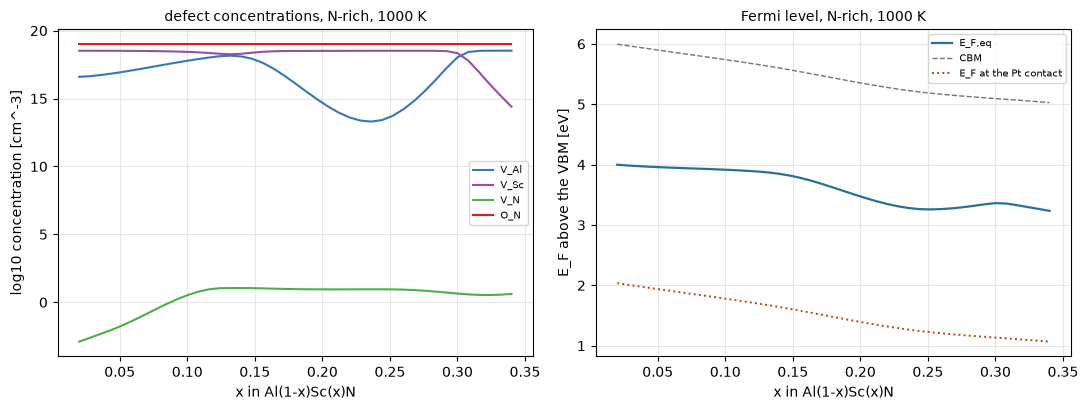


MODEL      4.2 bulk equilibrium
CONDITION  N-rich; no O_N at all; all compositions
           Delta mu_N = 0 (the reference corner the energies are stored at)
TEMPERATURE 1000 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV

      x      E_F   d_mu_N        V_Al        V_Sc         V_N
  0.042   3.0652    0.000   1.484e+03   9.084e+04   1.946e+01
  0.125   2.9763    0.000   2.536e+04   5.876e+04   1.243e+03
  0.250   2.5426    0.000   6.494e+02   5.097e+07   3.346e+03
  0.333   2.5441    0.000   4.784e+07   1.819e+04   6.621e+03


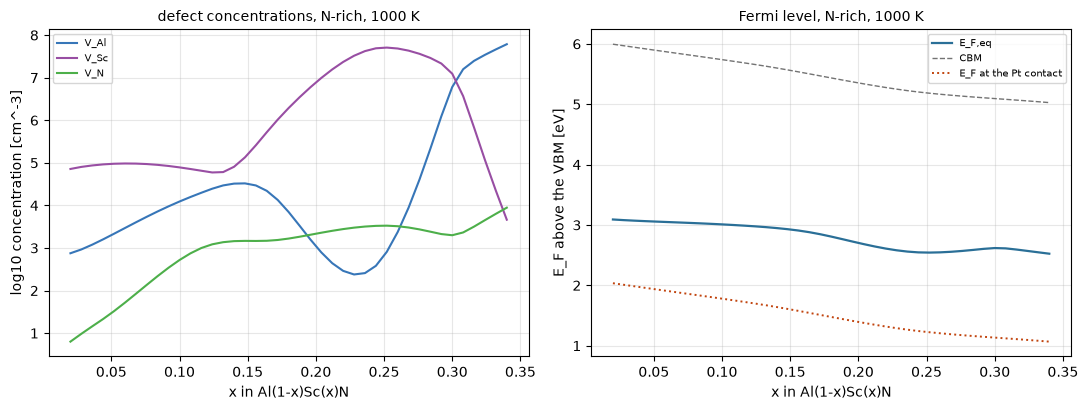

In [27]:
for variant in OXYGEN_VARIANTS:
    bulk_results(muN("N-rich"), muO(variant), temperature=1000.0)
    print()


#### 6.1.2 Most N-poor

MODEL      4.2 bulk equilibrium
CONDITION  most N-poor; [O_N] pinned at 1.0e+19 cm^-3; all compositions
           Delta mu_N from the SI most-N-poor vertex, about -3.2 eV
TEMPERATURE 1000 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV

      x      E_F   d_mu_N        V_Al        V_Sc         V_N         O_N
  0.042   5.0396   -3.220   6.203e+16   3.153e+18   3.520e+17   1.000e+19
  0.125   4.3127   -3.172   4.161e+08   6.054e+08   3.021e+18   1.000e+19
  0.250   3.8773   -3.172   1.011e+07   7.853e+11   3.344e+17   1.000e+19
  0.333   3.9616   -3.171   1.346e+13   5.104e+09   3.095e+17   1.000e+19


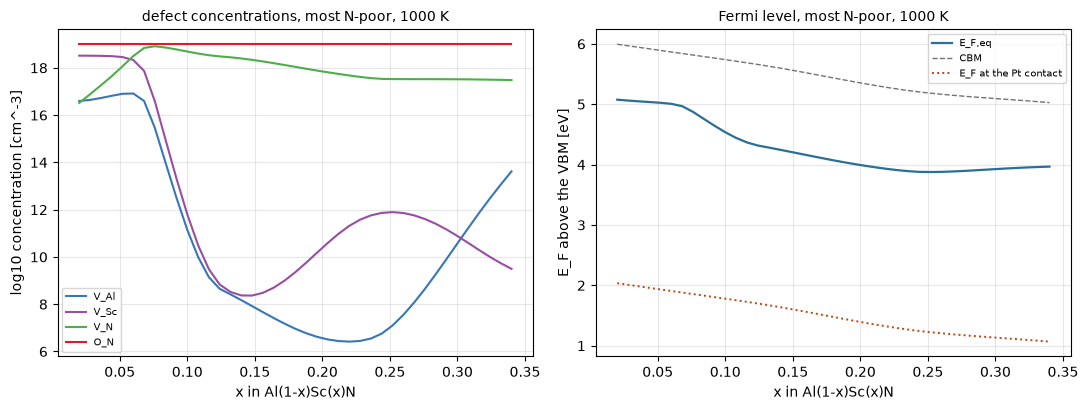


MODEL      4.2 bulk equilibrium
CONDITION  most N-poor; no O_N at all; all compositions
           Delta mu_N from the SI most-N-poor vertex, about -3.2 eV
TEMPERATURE 1000 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV

      x      E_F   d_mu_N        V_Al        V_Sc         V_N
  0.042   4.0494   -3.220   6.636e+01   3.373e+03   1.292e+14
  0.125   3.7050   -3.172   2.701e-01   3.931e-01   9.063e+16
  0.250   3.4185   -3.172   1.168e+00   9.073e+04   8.134e+16
  0.333   3.4850   -3.171   8.382e+05   3.177e+02   2.202e+16


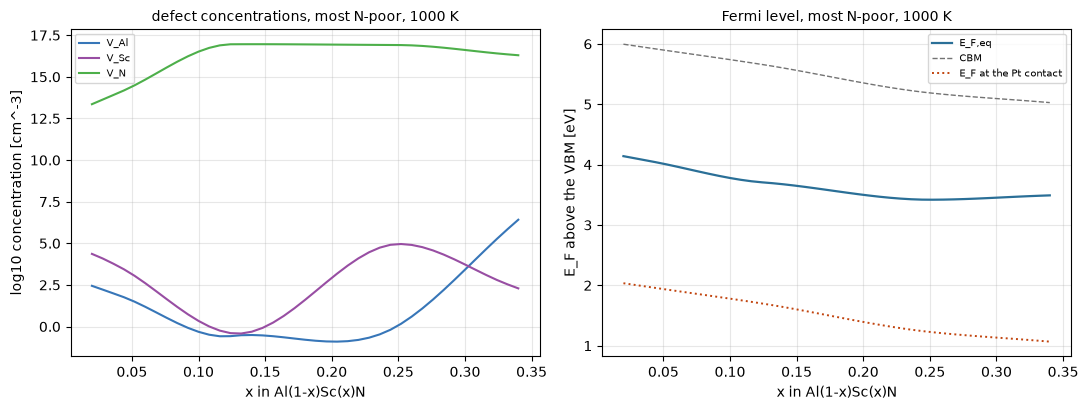

In [28]:
for variant in OXYGEN_VARIANTS:
    bulk_results(muN("most N-poor"), muO(variant), temperature=1000.0)
    print()


### 6.2 Depth-resolved, simplified freeze-in (4.3.1)

In [29]:
def depth_results(nitrogen, oxygen_condition, surface_temperature, lattice_temperature,
                  composition=0.25, depth_scales=("log", "linear")):
    """Depth figures for one chemical condition: energies, concentrations, charge, Fermi level."""
    potentials = nitrogen(composition)
    depths, fermi, charge, oxygen = grow_film(composition, surface_temperature,
                                              potentials, oxygen_condition)
    defects = defects_in_play(oxygen)
    contact = fermi_energy_at_electrode(composition)
    bulk = neutral_fermi_energy(composition, oxygen, surface_temperature, potentials)
    announce("4.3.1 simplified freeze-in", nitrogen, oxygen_condition, surface_temperature,
             composition, lattice_temperature)
    print(f"           dH taken from surface_formation_energies; "
          f"{FILM_THICKNESS_NM:.0f} nm grown as {len(depths)} planes {PLANE_SPACING_NM:.2f} nm "
          f"apart; Poisson mesh x{POISSON_MESH_MULTIPLIER}; "
          f"free surface: {FREE_SURFACE_CONDITION[0]} = {FREE_SURFACE_CONDITION[1]:.2e}")
    if "O_N" in defects:
        print(f"           delta mu_O = {oxygen:+.3f} eV, one value for the whole film")
    print(f"           each layer froze while it was the free surface, so the only boundary that "
          f"distinguishes them is the electrode at z = 0")
    print(f"           E_F at freeze-in: {contact:.3f} eV at the electrode (boundary condition), "
          f"{fermi[0]:.3f} eV in the first layer, {fermi[-1]:.3f} eV in the last")
    print(f"           thick-film limit E_F = {bulk:.3f} eV; last layer is "
          f"{abs(fermi[-1] - bulk) * 1e3:.2f} meV from it")
    permittivity = dielectric_constant(composition) * VACUUM_PERMITTIVITY_F_PER_CM
    screening = []
    for level in (fermi[0], bulk):
        slope = frozen_charge_and_slope(composition, level, oxygen, surface_temperature,
                                        potentials)[1]
        screening.append(math.sqrt(permittivity / abs(slope)) * 1.0e7 if slope else float("inf"))
    if screening[1] < depths[0]:
        verdict = ("UNRESOLVED even in the bulk - the model wants charge separated on less than "
                   "a lattice parameter, which it cannot have")
    elif screening[0] < depths[0]:
        verdict = "resolved in the bulk, not in the first layer"
    else:
        verdict = "resolved everywhere"
    print(f"           screening length {screening[0]:.2f} nm in the first layer, "
          f"{screening[1]:.2f} nm in the thick-film limit - {verdict}")
    populations = [surface_populations(composition, f, oxygen, surface_temperature,
                                       potentials) for f in fermi]
    crowded = [z for z, row in zip(depths, populations)
               if sublattice_occupancy(row, composition) > DILUTE_LIMIT_OCCUPANCY]
    if crowded:
        worst = max(sublattice_occupancy(row, composition) for row in populations)
        print(f"           WARNING dilute limit broken over z < {max(crowded):.2f} nm "
              f"({len(crowded)} of {len(depths)} planes, peak occupancy {worst:.1%}) - the "
              f"formation energies do not apply there")
    ground = {d: [lowest_charge_state(surface_formation_energies, d, composition, f,
                                      potentials, oxygen) for f in fermi]
              for d in defects}
    for defect in defects:
        states = [state for state, _ in ground[defect]]
        order = sorted(set(states), key=states.index)
        if len(order) == 1:
            print(f"           {defect:<5s} ground state q = {order[0]:+d} at every depth")
        else:
            flips = ", ".join(f"{a:+d}->{b:+d} at {depths[i]:.2f} nm"
                              for i, (a, b) in enumerate(zip(states, states[1:]), start=1)
                              if a != b)
            print(f"           {defect:<5s} ground state changes: {flips}")
    if not HAVE_MATPLOTLIB:
        return
    used = {state for pairs in ground.values() for state, _ in pairs}

    electrons = [carrier_concentrations(composition, f, lattice_temperature)[0] for f in fermi]
    holes = [carrier_concentrations(composition, f, lattice_temperature)[1] for f in fermi]
    for scale in depth_scales:
      figure, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
      for defect in defects:
          states = [state for state, _ in ground[defect]]
          plot_by_charge_state(axes[0], depths, states, [e for _, e in ground[defect]], defect)
      axes[0].set_ylabel("dH of the ground-state charge [eV]")
      axes[0].set_title(f"dH of the lowest-energy charge state, x = {composition}", fontsize=10)
      charge_state_legend(axes[0], used, defects)

      for defect in defects:
          totals = [sum(row[(defect, state)] for state in DEFECT_CHARGE_STATES[defect])
                    for row in populations]
          axes[1].plot(depths, [math.log10(max(value, 1e-30)) for value in totals],
                       color=DEFECT_COLOURS[defect], linewidth=1.6, label=defect)
      axes[1].set_ylabel("log10 total concentration [cm^-3]")
      axes[1].set_title(f"frozen-in concentration, summed over charge states, x = {composition}",
                        fontsize=10)
      axes[1].legend(fontsize=7)

      axes[2].plot(depths, [c / ELEMENTARY_CHARGE_C for c in charge], "-", color="#1b1b1b",
                   linewidth=1.6, label="net defect charge")
      axes[2].plot(depths, electrons, "--", color="#2a6f97", linewidth=1.4, label="electrons n")
      axes[2].plot(depths, holes, ":", color="#c1440e", linewidth=1.4, label="holes p")
      axes[2].set_yscale("symlog", linthresh=1.0)
      axes[2].set_ylabel("charge density [e/cm^3] / carriers [cm^-3]")
      axes[2].set_title(f"net charge and carriers, x = {composition}", fontsize=10)
      axes[2].legend(fontsize=7)

      for axis in axes:
          axis.set_xlabel(f"depth z [nm], {scale} scale")
          axis.set_xscale(scale)
          axis.grid(alpha=0.3)
      plt.tight_layout()
      plt.show()

    for scale in depth_scales:
        figure, axis = plt.subplots(figsize=(5.5, 4.2))
        axis.plot(depths, fermi, "-", color="#c1440e", linewidth=1.6, label="E_F(z)")
        axis.axhline(BAND_GAP_INTERPOLANT(composition), linestyle="--", color="0.45",
                     linewidth=1.0, label="CBM")
        axis.axhline(0.0, linestyle="--", color="0.7", linewidth=1.0, label="VBM")
        axis.set_xlabel(f"depth z [nm], {scale} scale")
        axis.set_xscale(scale)
        axis.set_ylabel("E_F at freeze-in, above the local VBM [eV]")
        axis.set_title(f"Fermi level each layer froze at, x = {composition}, "
                       f"{nitrogen.label}", fontsize=10)
        axis.legend(fontsize=8)
        axis.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


#### 6.2.1 N-rich

MODEL      4.3.1 simplified freeze-in
CONDITION  N-rich; [O_N] pinned at 1.0e+19 cm^-3; x = 0.25
           Delta mu_N = 0 (the reference corner the energies are stored at)
TEMPERATURE 1200 K; charge states equilibrate at 673 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV
           dH taken from surface_formation_energies; 100 nm grown as 400 planes 0.25 nm apart; Poisson mesh x1; free surface: charge = 9.92e+11
           delta mu_O = +0.380 eV, one value for the whole film
           each layer froze while it was the free surface, so the only boundary that distinguishes them is the electrode at z = 0
           E_F at freeze-in: 1.228 eV at the electrode (boundary condition), 2.372 eV in the first layer, 3.211 eV in the last
           thick-film limit E_F = 3.211 eV; last layer is 0.26 meV from it
           screening length 0.10 nm in the first layer, 1.64 nm in the thick-film limit - resolved in the bulk, not in the first layer
           WARNING dilute limit broken over z < 0.75 nm (

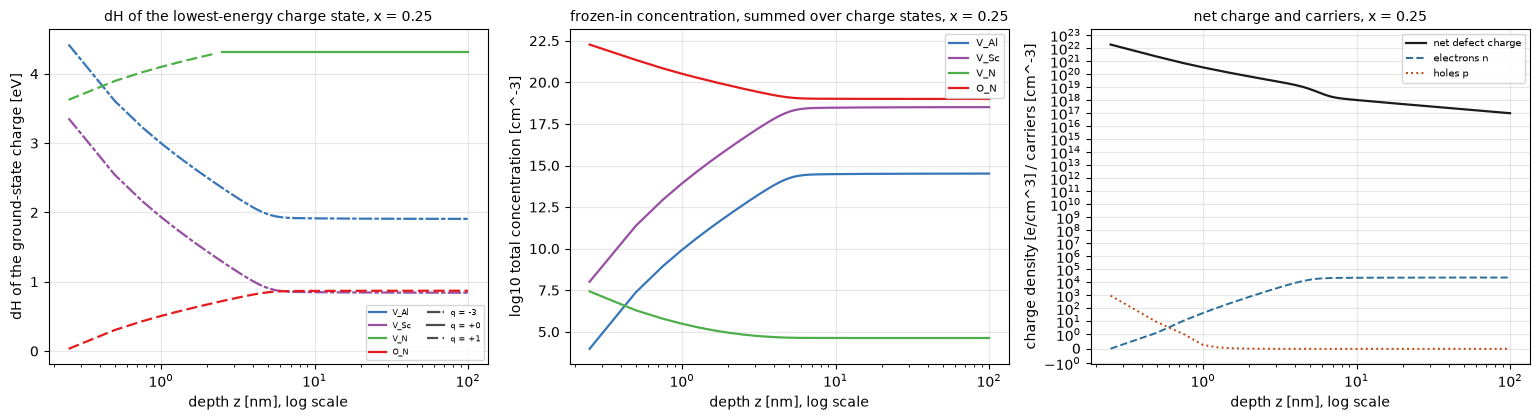

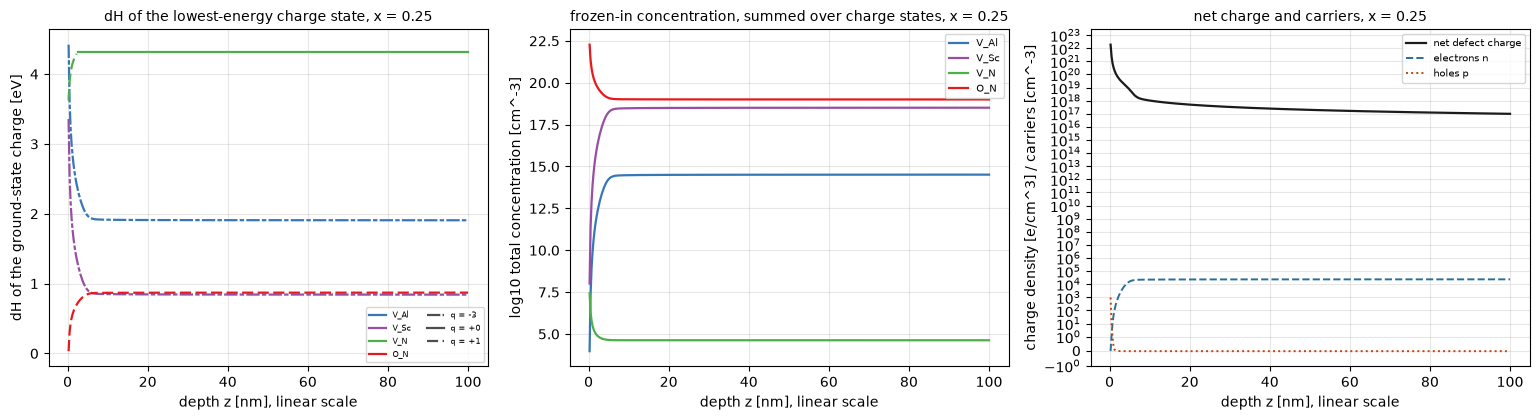

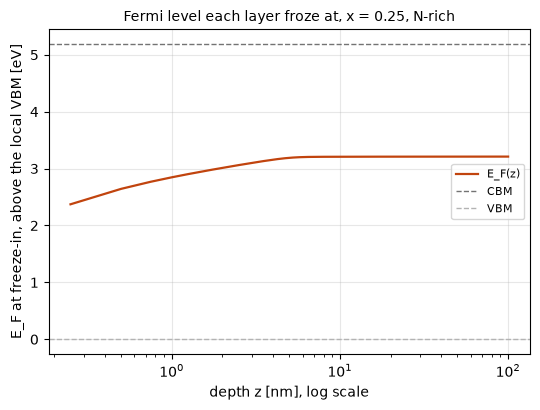

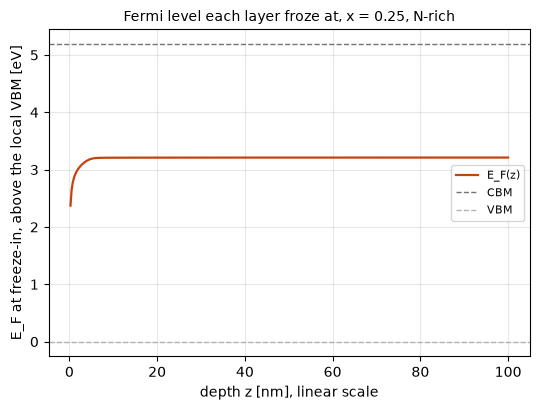


MODEL      4.3.1 simplified freeze-in
CONDITION  N-rich; no O_N at all; x = 0.25
           Delta mu_N = 0 (the reference corner the energies are stored at)
TEMPERATURE 1200 K; charge states equilibrate at 673 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV
           dH taken from surface_formation_energies; 100 nm grown as 400 planes 0.25 nm apart; Poisson mesh x1; free surface: charge = 9.92e+11
           each layer froze while it was the free surface, so the only boundary that distinguishes them is the electrode at z = 0
           E_F at freeze-in: 1.228 eV at the electrode (boundary condition), 1.226 eV in the first layer, 1.196 eV in the last
           thick-film limit E_F = 2.309 eV; last layer is 1112.89 meV from it
           screening length 28.31 nm in the first layer, 733246.27 nm in the thick-film limit - resolved everywhere
           V_Al  ground state q = +0 at every depth
           V_Sc  ground state q = +0 at every depth
           V_N   ground state q = +3 at every de

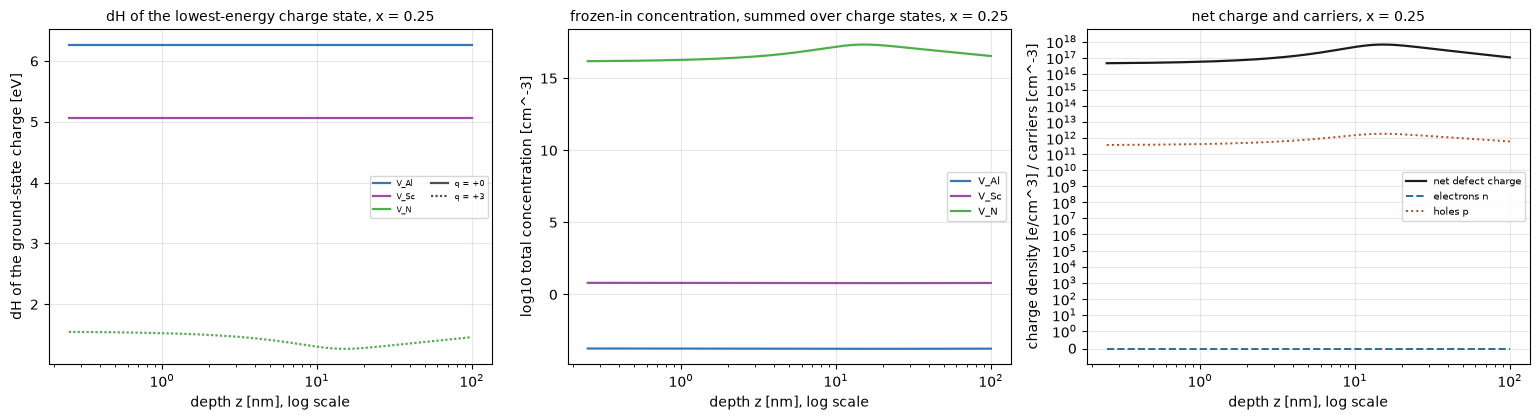

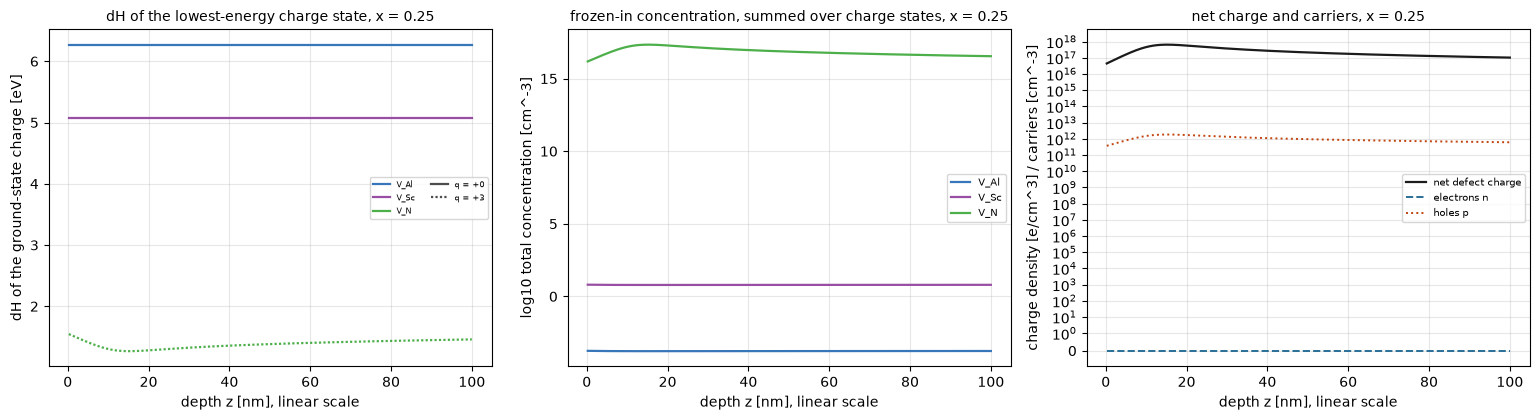

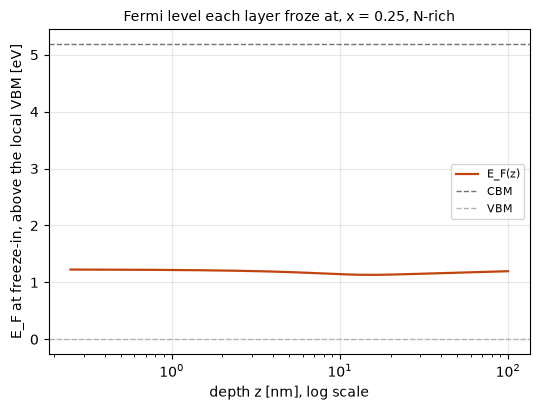

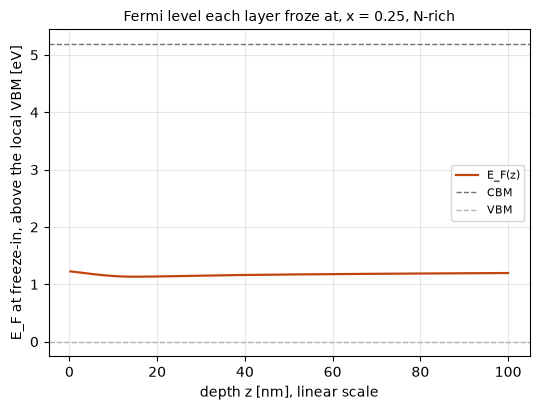

In [30]:
for variant in OXYGEN_VARIANTS:
    depth_results(muN("N-rich"), muO(variant),
                  surface_temperature=EFFECTIVE_SURFACE_TEMPERATURE,
                  lattice_temperature=DEPOSITION_TEMPERATURE)
    print()


#### 6.2.2 Most N-poor

MODEL      4.3.1 simplified freeze-in
CONDITION  most N-poor; [O_N] pinned at 1.0e+19 cm^-3; x = 0.25
           Delta mu_N from the SI most-N-poor vertex, about -3.2 eV
TEMPERATURE 1200 K; charge states equilibrate at 673 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV
           dH taken from surface_formation_energies; 100 nm grown as 400 planes 0.25 nm apart; Poisson mesh x1; free surface: charge = 9.92e+11
           delta mu_O = -2.413 eV, one value for the whole film
           each layer froze while it was the free surface, so the only boundary that distinguishes them is the electrode at z = 0
           E_F at freeze-in: 1.228 eV at the electrode (boundary condition), 2.701 eV in the first layer, 3.807 eV in the last
           thick-film limit E_F = 3.812 eV; last layer is 4.52 meV from it
           screening length 0.10 nm in the first layer, 6.81 nm in the thick-film limit - resolved in the bulk, not in the first layer
           WARNING dilute limit broken over z < 0.75 nm (3 o

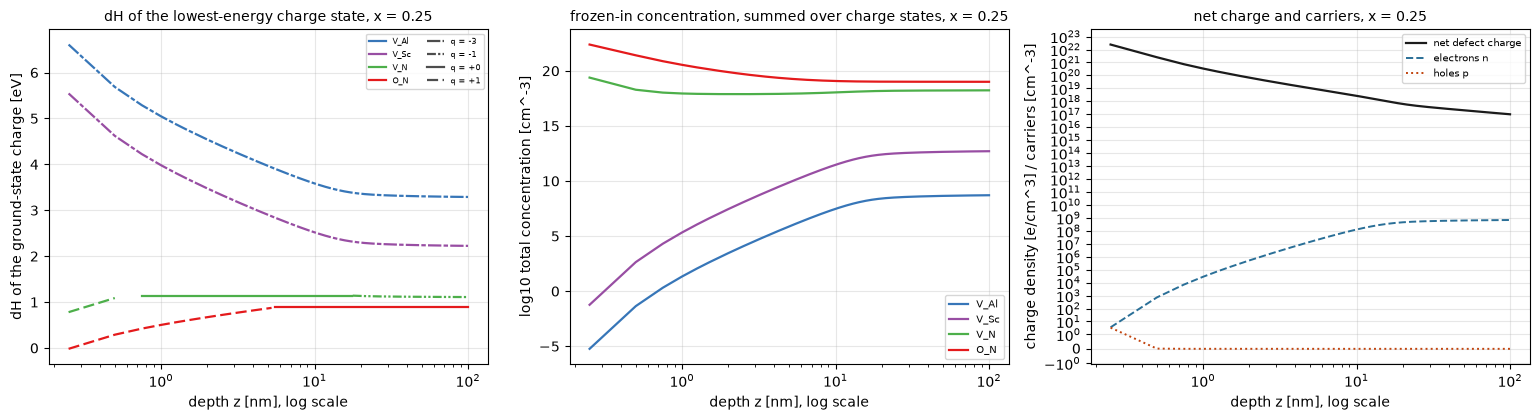

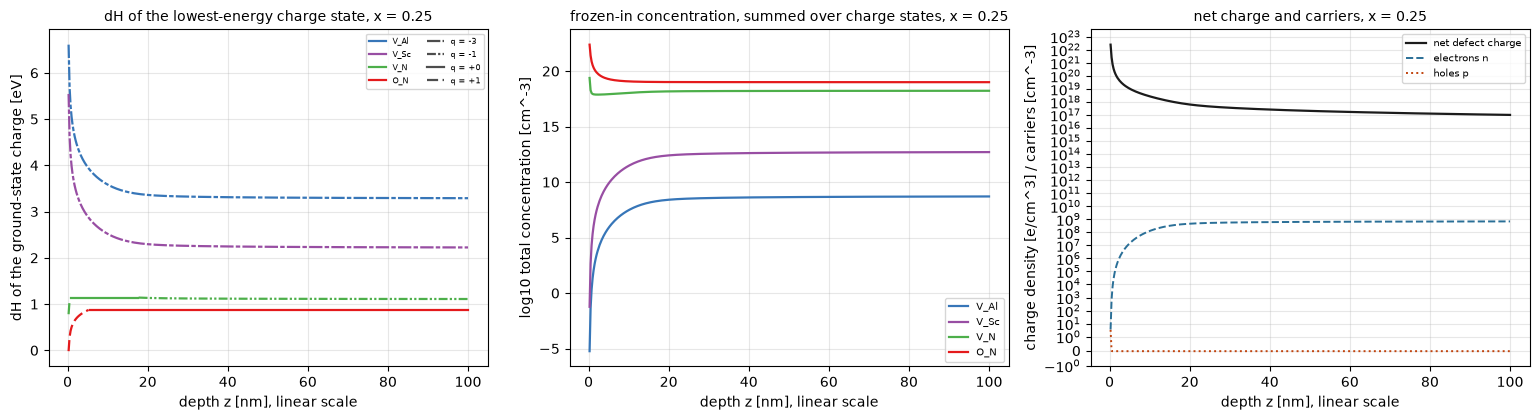

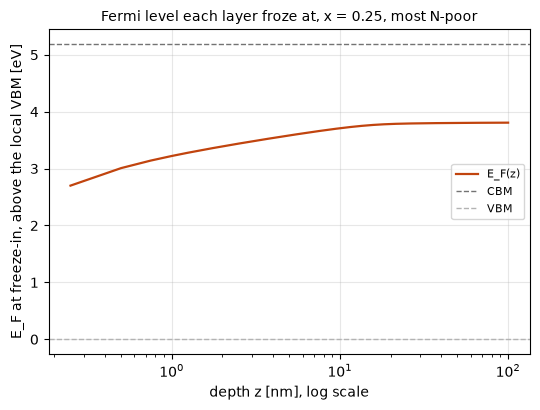

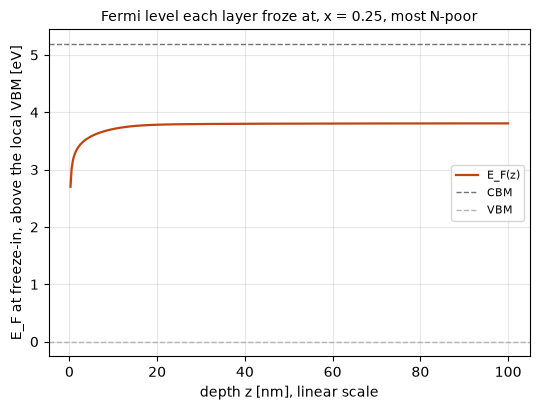


MODEL      4.3.1 simplified freeze-in
CONDITION  most N-poor; no O_N at all; x = 0.25
           Delta mu_N from the SI most-N-poor vertex, about -3.2 eV
TEMPERATURE 1200 K; charge states equilibrate at 673 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV
           dH taken from surface_formation_energies; 100 nm grown as 400 planes 0.25 nm apart; Poisson mesh x1; free surface: charge = 9.92e+11
           each layer froze while it was the free surface, so the only boundary that distinguishes them is the electrode at z = 0
           E_F at freeze-in: 1.228 eV at the electrode (boundary condition), 2.050 eV in the first layer, 3.250 eV in the last
           thick-film limit E_F = 3.419 eV; last layer is 168.06 meV from it
           screening length 0.09 nm in the first layer, 48.38 nm in the thick-film limit - resolved in the bulk, not in the first layer
           WARNING dilute limit broken over z < 0.75 nm (3 of 400 planes, peak occupancy 25.7%) - the formation energies do not apply th

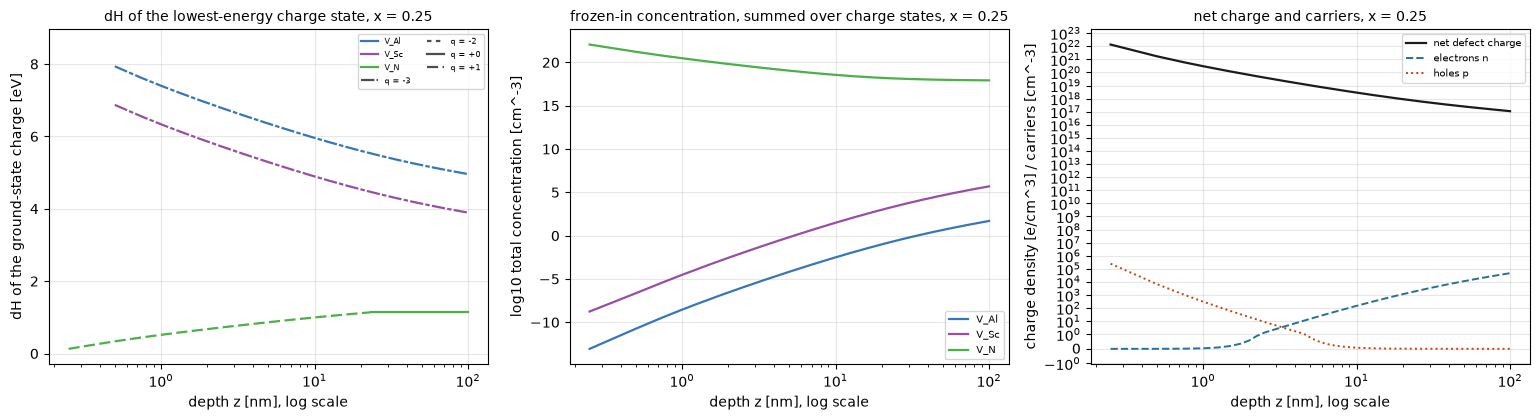

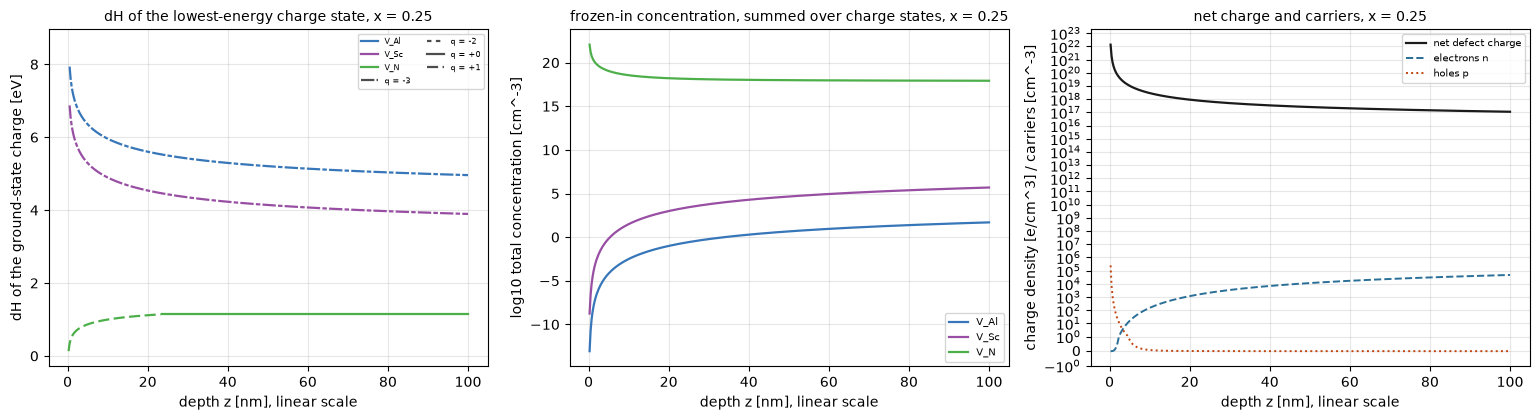

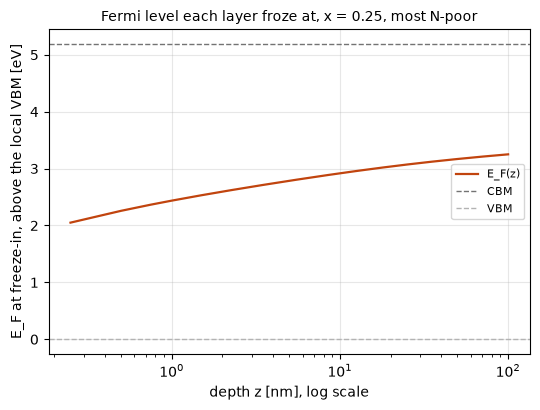

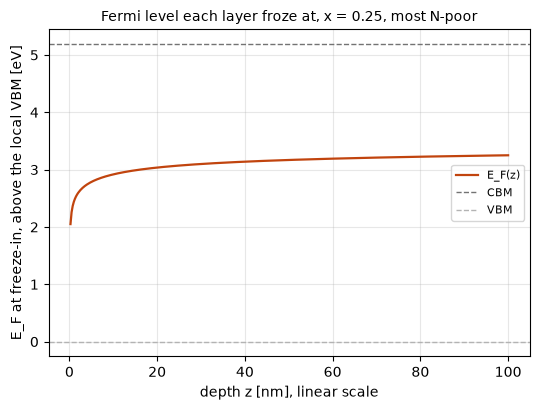

In [31]:
for variant in OXYGEN_VARIANTS:
    depth_results(muN("most N-poor"), muO(variant),
                  surface_temperature=EFFECTIVE_SURFACE_TEMPERATURE,
                  lattice_temperature=DEPOSITION_TEMPERATURE)
    print()


#### 6.2.3 Mesh convergence

Two meshes, and they behave completely differently.

**The Poisson mesh does nothing.** Charge sits on discrete planes, so the exact φ(z) is piecewise linear between them — and the finite-difference Laplacian is exact for linear functions. Refining it cannot change the answer, and the m = 1 and m = 4 columns below agree to every digit printed. The multiplier is kept so that claim stays checkable rather than asserted.

**The charge mesh is physics, not numerics.** Its value is the plane spacing c/2, so it is not free to refine: halving it would mean inventing lattice planes that do not exist. The sweep is there to show how much of the near-contact answer rests on that spacing — the profile converges from below, and at c/2 the first nanometre still carries a few tens of meV that the discreteness of the lattice puts there.

In [32]:
def mesh_convergence(nitrogen, oxygen_condition, surface_temperature, composition=0.25,
                     multipliers=(1, 4), spacings=(1.0, 0.5, 0.25, 0.125),
                     probes=(1.0, 2.0, 5.0, 20.0)):
    """Both meshes, side by side: the Poisson multiplier and the charge-plane spacing."""
    potentials = nitrogen(composition)
    announce("4.3.1 mesh convergence", nitrogen, oxygen_condition, surface_temperature,
             composition)
    print()
    print(f"Poisson mesh, charge planes fixed at {PLANE_SPACING_NM:.2f} nm")
    runs = [grow_film(composition, surface_temperature, potentials, oxygen_condition, m)
            for m in multipliers]
    depths = runs[0][0]
    print(f"{'z (nm)':>8s}" + "".join(f"{'E_F(m=%d)' % m:>12s}" for m in multipliers)
          + f"{'spread':>12s}")
    for index in (0, 1, 3, 9, 49, len(depths) - 1):
        values = [run[1][index] for run in runs]
        print(f"{depths[index]:8.2f}" + "".join(f"{value:12.4f}" for value in values)
              + f"{(max(values) - min(values)) * 1e3:9.2f} meV")
    worst = max(abs(a - b) for a, b in zip(runs[0][1], runs[-1][1]))
    print(f"   largest difference anywhere: {worst * 1e3:.3f} meV "
          f"- the Poisson mesh is exact for plane charges, so this is round-off")
    print()
    print("Charge-plane spacing, at fixed depths (Poisson mesh x1)")
    print(f"{'spacing':>9s}" + "".join(f"{'E_F(z=%.0f)' % z:>13s}" for z in probes))
    for spacing in spacings:
        _, fermi, _, _ = grow_film(composition, surface_temperature, potentials,
                                   oxygen_condition, 1, spacing)
        row = []
        for target in probes:
            index = min(range(len(fermi)), key=lambda k: abs((k + 1) * spacing - target))
            row.append(fermi[index])
        flag = "   <- the lattice value, c/2" if abs(spacing - PLANE_SPACING_NM) < 1e-9 else ""
        print(f"{spacing:9.3f}" + "".join(f"{value:13.4f}" for value in row) + flag)


In [33]:
mesh_convergence(muN("N-rich"), muO(OXYGEN_CONDITION),
                 surface_temperature=EFFECTIVE_SURFACE_TEMPERATURE)


MODEL      4.3.1 mesh convergence
CONDITION  N-rich; [O_N] pinned at 1.0e+19 cm^-3; x = 0.25
           Delta mu_N = 0 (the reference corner the energies are stored at)
TEMPERATURE 1200 K
ELECTRODE  Pt N-polar, Phi_Bn = 3.96 eV

Poisson mesh, charge planes fixed at 0.25 nm
  z (nm)    E_F(m=1)    E_F(m=4)      spread
    0.25      2.3725      2.3725     0.00 meV
    0.50      2.6438      2.6438     0.00 meV
    1.00      2.8466      2.8466     0.00 meV
    2.50      3.0613      3.0613     0.00 meV
   12.50      3.2088      3.2088     0.00 meV
  100.00      3.2107      3.2107     0.00 meV
   largest difference anywhere: 0.000 meV - the Poisson mesh is exact for plane charges, so this is round-off

Charge-plane spacing, at fixed depths (Poisson mesh x1)
  spacing     E_F(z=1)     E_F(z=2)     E_F(z=5)    E_F(z=20)
    1.000       2.6869       2.9398       3.1725       3.2097
    0.500       2.7975       2.9913       3.1843       3.2097
    0.250       2.8466       3.0124       3.1890    

### 6.3 Electrode barriers on offer

Every metal and polarity in section 2.1.4, so the one the model actually uses can be seen against the alternatives. Phi_Bn is held at its AlN value and Phi_Bp = E_g(x) - Phi_Bn takes up the whole gap change, which is the approximation 2.1.4.2 argues for. Phi_Bp is the Dirichlet condition at z = 0, so it is the curve the depth model is sensitive to.

IN USE for every other figure in section 6: Pt N-polar, route A, Phi_Bn = 3.96 eV
   -> Phi_Bp = 1.228 eV at x = 0.25, which is where E_F sits at the contact
   route A: direct DFT on M/AlN (Guo 2020, HSE), corrected for work function
   route B: via a virtual M/GaN/AlN stack (Liu 2026); N-polar only, Au and Pt only


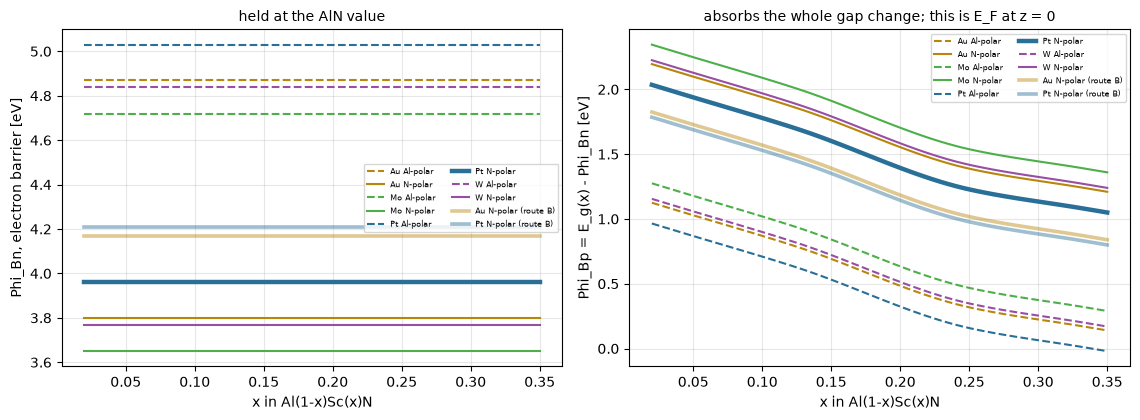

In [34]:
def electrode_barrier_survey():
    """Phi_Bn and Phi_Bp against x for every tabulated metal, polarity and route."""
    print(f"IN USE for every other figure in section 6: {ELECTRODE_METAL} "
          f"{ELECTRODE_POLARITY}, route A, Phi_Bn = {ELECTRODE_ELECTRON_BARRIER:.2f} eV")
    print(f"   -> Phi_Bp = {fermi_energy_at_electrode(0.25):.3f} eV at x = 0.25, which is where "
          f"E_F sits at the contact")
    print("   route A: direct DFT on M/AlN (Guo 2020, HSE), corrected for work function")
    print("   route B: via a virtual M/GaN/AlN stack (Liu 2026); N-polar only, Au and Pt only")
    if not HAVE_MATPLOTLIB:
        return
    grid = [0.02 + 0.33 * index / 60.0 for index in range(61)]
    figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
    styles = {"Al-polar": "--", "N-polar": "-"}
    colours = {"Au": "#b8860b", "Pt": "#2a6f97", "Mo": "#4daf4a", "W": "#984ea3"}
    for route, table, width in (("A", SCHOTTKY_BARRIER_ALN_ROUTE_A, 1.5),
                                ("B", SCHOTTKY_BARRIER_ALN_ROUTE_B, 2.6)):
        for (metal, polarity), (_, electron_barrier) in sorted(table.items()):
            chosen = (route == "A" and metal == ELECTRODE_METAL
                      and polarity == ELECTRODE_POLARITY)
            label = f"{metal} {polarity}" + ("" if route == "A" else " (route B)")
            axes[0].plot(grid, [electron_barrier] * len(grid), styles[polarity],
                         color=colours[metal], linewidth=3.2 if chosen else width,
                         alpha=1.0 if route == "A" else 0.45, label=label)
            axes[1].plot(grid, [electrode_barriers(electron_barrier, x)[0] for x in grid],
                         styles[polarity], color=colours[metal],
                         linewidth=3.2 if chosen else width,
                         alpha=1.0 if route == "A" else 0.45, label=label)
    axes[0].set_ylabel("Phi_Bn, electron barrier [eV]")
    axes[0].set_title("held at the AlN value", fontsize=10)
    axes[1].set_ylabel("Phi_Bp = E_g(x) - Phi_Bn [eV]")
    axes[1].set_title("absorbs the whole gap change; this is E_F at z = 0", fontsize=10)
    for axis in axes:
        axis.set_xlabel("x in Al(1-x)Sc(x)N")
        axis.grid(alpha=0.3)
        axis.legend(fontsize=6, ncol=2)
    plt.tight_layout()
    plt.show()


electrode_barrier_survey()
